# Healthcare Risk Prediction System using Machine Learning

## 1. Introduction

Chronic diseases such as stroke, diabetes, and hypertension are among the leading contributors to global mortality and long-term disability. Early identification of individuals at risk plays a crucial role in preventive healthcare and clinical decision support systems.

In this project, we develop a machine learning-based multi-disease risk prediction framework using structured health survey data (BRFSS-based features). The system is designed to:

- Build and evaluate predictive models for three major chronic conditions
- Compare multiple supervised learning algorithms under a unified evaluation framework
- Analyze model performance under real-world conditions such as class imbalance and heterogeneous feature distributions
- Identify disease-specific optimal models based on empirical performance

Rather than treating each disease as an isolated problem, this work emphasizes a **comparative modeling framework**, enabling systematic evaluation of how different algorithms behave across multiple clinical prediction tasks.

The final objective is to derive a robust, interpretable, and reproducible ML pipeline suitable for real-world healthcare risk stratification.

**Importing Libraries**

In [ ]:
# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

# Machine Learning models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    RocCurveDisplay
)
from sklearn import metrics

# 2. Dataset Overview

## 2.1 Dataset Source

This project utilizes the BRFSS (Behavioral Risk Factor Surveillance System) dataset, which is a large-scale health-related survey dataset collected to monitor public health conditions and risk behaviors in the population.

The dataset contains structured health indicators related to lifestyle, chronic conditions, and demographic attributes.

---

## 2.2 Prediction Targets

The dataset is used to build predictive models for three major health outcomes:

- Stroke
- Hypertension (HighBP)
- Diabetes

Each target is treated as an independent binary classification problem.

---

## 2.3 Feature Space

The dataset consists of multiple health-related attributes such as:

- Demographic features (Age, Sex)
- Lifestyle indicators (Smoking, Physical Activity, Alcohol Consumption)
- Clinical measurements (BMI, Cholesterol, Blood Pressure)
- General health indicators (Physical Health, Mental Health)

These features provide a multi-dimensional representation of an individual's health profile.

---

## 2.4 Problem Type

This is a supervised machine learning problem involving:

- Binary classification
- Multi-target modeling
- Imbalanced dataset learning challenges

---

## 2.5 Motivation

The goal is to analyze how different machine learning models perform across multiple related health conditions and to evaluate their robustness under real-world medical data distributions.

# 3. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the structure, distribution, and relationships within the dataset before applying machine learning models.

The objective of this stage is to identify:
- Class imbalance in target variables
- Distribution of key health indicators
- Potential relationships between features and disease outcomes
- Data quality issues such as missing values or outliers

In [ ]:
# Load the dataset
df = pd.read_csv("data/diabetes_data.csv")

# Display all columns when printing DataFrames
pd.set_option("display.max_columns", None)

# Preview the dataset; Display the first five rows
display(df.head())

# Display the dataset dimensions
print(f"Dataset Shape: {df.shape}")

,Age,Sex,HighChol,CholCheck,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Stroke,HighBP,Diabetes
0,4.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,5.0,30.0,0.0,0.0,1.0,0.0
1,12.0,1.0,1.0,1.0,26.0,1.0,0.0,0.0,1.0,0.0,0.0,3.0,0.0,0.0,0.0,1.0,1.0,0.0
2,13.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,10.0,0.0,0.0,0.0,0.0
3,11.0,1.0,1.0,1.0,28.0,1.0,0.0,1.0,1.0,1.0,0.0,3.0,0.0,3.0,0.0,0.0,1.0,0.0
4,8.0,0.0,0.0,1.0,29.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0


Dataset Shape: (70692, 18)


In [ ]:
# Dataset Information
print("Dataset Information:\n")
df.info()


# Data Quality Check
print("\nMissing Values:")
display(df.isnull().sum())

print(f"\nDuplicate Records: {df.duplicated().sum()}")


# Note:
# Duplicate rows were retained because the dataset does not contain a unique patient ID.
# Identical feature values may represent different individuals with the same health profile,
# so removing them could distort the real-world data distribution.

Dataset Information:

<class 'pandas.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   70692 non-null  float64
 1   Sex                   70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   HeartDiseaseorAttack  70692 non-null  float64
 7   PhysActivity          70692 non-null  float64
 8   Fruits                70692 non-null  float64
 9   Veggies               70692 non-null  float64
 10  HvyAlcoholConsump     70692 non-null  float64
 11  GenHlth               70692 non-null  float64
 12  MentHlth              70692 non-null  float64
 13  PhysHlth              70692 non-null  float64
 14  DiffWalk              70692 non-null  float64
 15  Stroke  

Age                     0
Sex                     0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Stroke                  0
HighBP                  0
Diabetes                0
dtype: int64


Duplicate Records: 6672


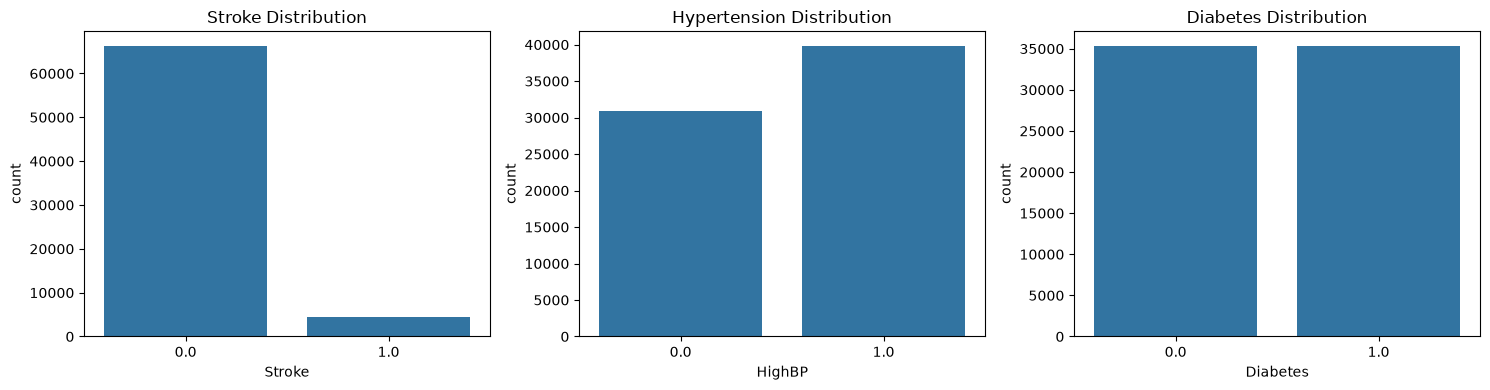

In [ ]:
# Visualize the distribution of Target Variables

targets = {
    "Stroke": "Stroke",
    "HighBP": "Hypertension",
    "Diabetes": "Diabetes"
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (column, title) in zip(axes, targets.items()):
    sns.countplot(data=df, x=column, ax=ax)
    ax.set_title(f"{title} Distribution")

plt.tight_layout()
plt.show()

In [ ]:
# Inspect Unique Values in Each Feature

unique_values = pd.DataFrame({
    "Unique Values": df.nunique()
})

unique_values

,Unique Values
Age,13
Sex,2
HighChol,2
CholCheck,2
BMI,80
Smoker,2
HeartDiseaseorAttack,2
PhysActivity,2
Fruits,2
Veggies,2


In [ ]:
# Generate Descriptive Statistics

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,70692.0,8.584055,2.852153,1.0,7.0,9.0,11.0,13.0
Sex,70692.0,0.456997,0.498151,0.0,0.0,0.0,1.0,1.0
HighChol,70692.0,0.525703,0.499342,0.0,0.0,1.0,1.0,1.0
CholCheck,70692.0,0.975259,0.155336,0.0,1.0,1.0,1.0,1.0
BMI,70692.0,29.856985,7.113954,12.0,25.0,29.0,33.0,98.0
Smoker,70692.0,0.475273,0.499392,0.0,0.0,0.0,1.0,1.0
HeartDiseaseorAttack,70692.0,0.147810,0.354914,0.0,0.0,0.0,0.0,1.0
PhysActivity,70692.0,0.703036,0.456924,0.0,0.0,1.0,1.0,1.0
Fruits,70692.0,0.611795,0.487345,0.0,0.0,1.0,1.0,1.0
Veggies,70692.0,0.788774,0.408181,0.0,1.0,1.0,1.0,1.0


In [ ]:
# Select Categorical and Ordinal Features for Visualization

# Note:
# BMI, MentHlth, and PhysHlth are excluded because they are continuous
# numerical variables. They will be explored separately using distribution-
# based visualizations (e.g., histograms and boxplots), while the following
# features are best represented using count plots.

categorical_features = [
    "Age",
    "Sex",
    "HighChol",
    "CholCheck",
    "Smoker",
    "HeartDiseaseorAttack",
    "PhysActivity",
    "Fruits",
    "Veggies",
    "HvyAlcoholConsump",
    "GenHlth",
    "DiffWalk",
    "Stroke",
    "HighBP",
    "Diabetes"
]

In [ ]:
'''
#og
# Visualize Categorical and Ordinal Feature Distributions

# Note:
# BMI, MentHlth, and PhysHlth are excluded because they are continuous
# numerical variables. Their distributions will be analyzed separately.

fig, axes = plt.subplots(5, 3, figsize=(18, 22))
axes = axes.flatten()

for ax, feature in zip(axes, categorical_features):
    sns.countplot(
        data=df,
        y=feature,
        order=df[feature].value_counts().index,
        color=sns.color_palette("flare")[4],
        ax=ax
    )

    ax.set_title(feature, fontsize=12, fontweight="bold")
    ax.set_xlabel("Count")
    ax.set_ylabel("")

# Remove any unused subplot
for ax in axes[len(categorical_features):]:
    fig.delaxes(ax)

plt.suptitle(
    "Distribution of Categorical and Ordinal Features",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

'''

'\n#og\n# Visualize Categorical and Ordinal Feature Distributions\n\n# Note:\n# BMI, MentHlth, and PhysHlth are excluded because they are continuous\n# numerical variables. Their distributions will be analyzed separately.\n\nfig, axes = plt.subplots(5, 3, figsize=(18, 22))\naxes = axes.flatten()\n\nfor ax, feature in zip(axes, categorical_features):\n    sns.countplot(\n        data=df,\n        y=feature,\n        order=df[feature].value_counts().index,\n        color=sns.color_palette("flare")[4],\n        ax=ax\n    )\n\n    ax.set_title(feature, fontsize=12, fontweight="bold")\n    ax.set_xlabel("Count")\n    ax.set_ylabel("")\n\n# Remove any unused subplot\nfor ax in axes[len(categorical_features):]:\n    fig.delaxes(ax)\n\nplt.suptitle(\n    "Distribution of Categorical and Ordinal Features",\n    fontsize=18,\n    fontweight="bold"\n)\n\nplt.tight_layout(rect=[0, 0, 1, 0.98])\nplt.show()\n\n'

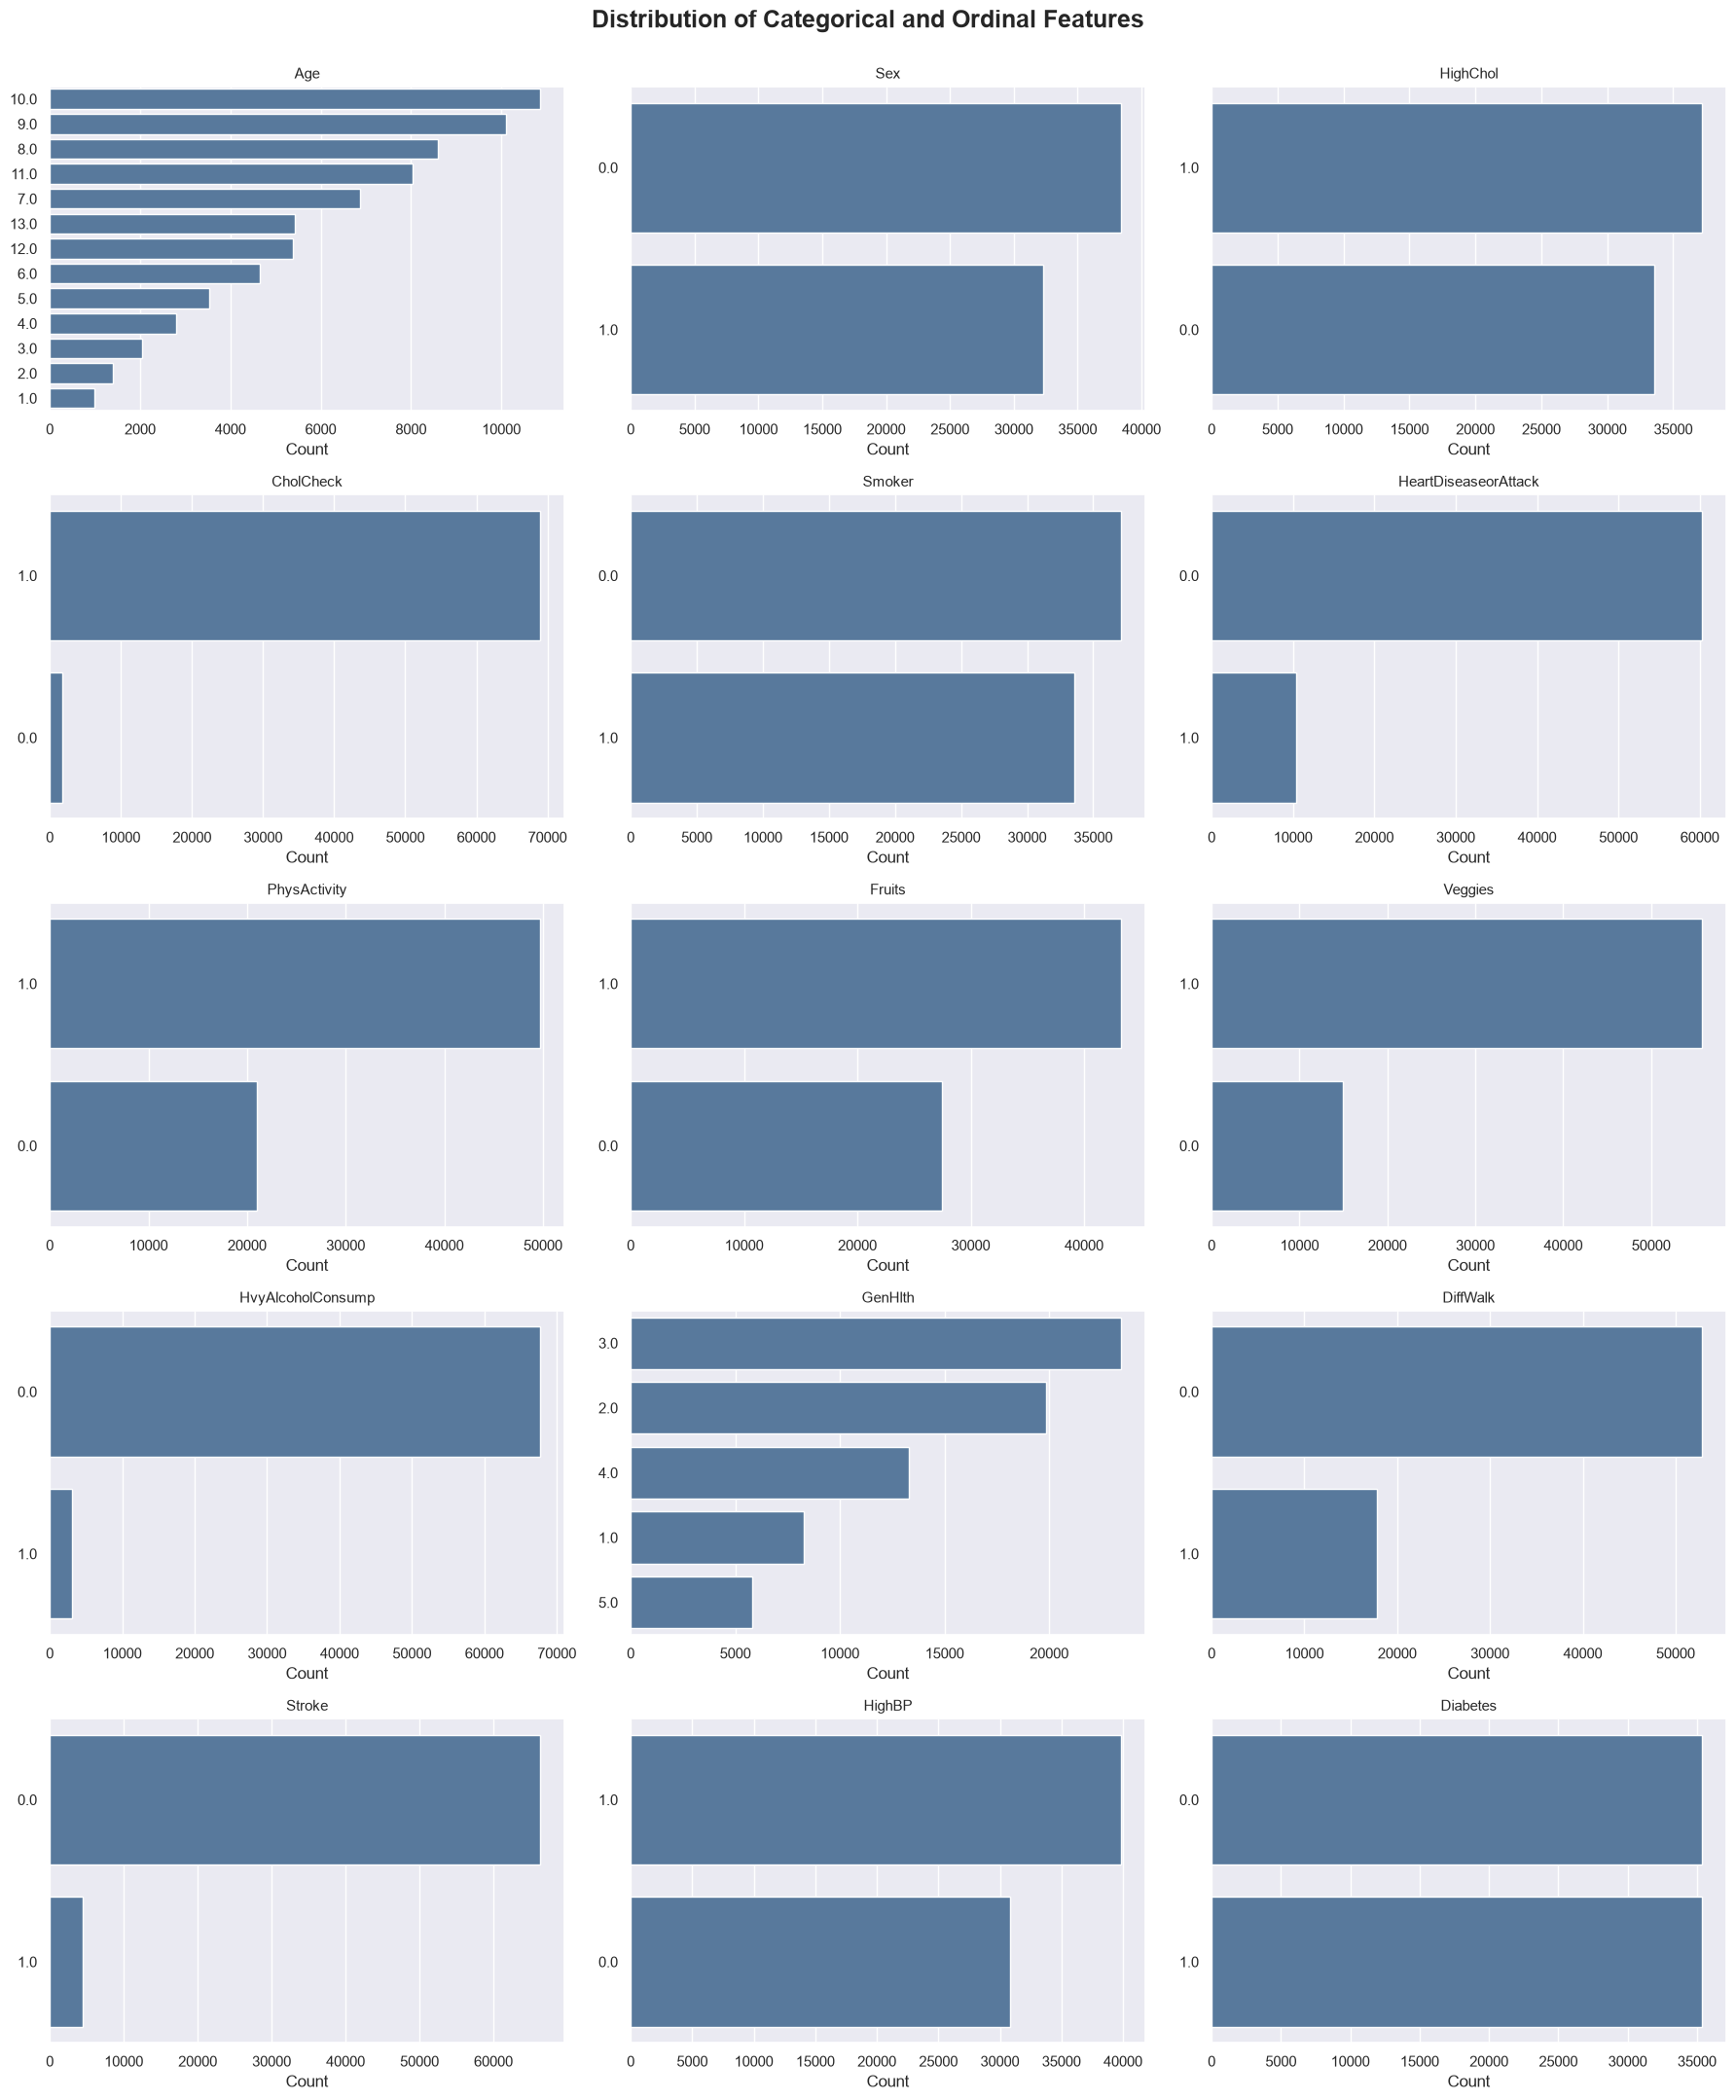

In [ ]:
# 01
# Visualize Categorical and Ordinal Feature Distributions

sns.set_theme(
    style="darkgrid",
    context="notebook"
)

fig, axes = plt.subplots(5, 3, figsize=(18, 22))
axes = axes.flatten()

for ax, feature in zip(axes, categorical_features):

    sns.countplot(
        data=df,
        y=feature,
        order=df[feature].value_counts().index,
        color="#4C78A8",
        ax=ax
    )

    ax.set_title(feature, fontsize=11)
    ax.set_xlabel("Count")
    ax.set_ylabel("")

# Remove unused subplot
for ax in axes[len(categorical_features):]:
    fig.delaxes(ax)

plt.suptitle(
    "Distribution of Categorical and Ordinal Features",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

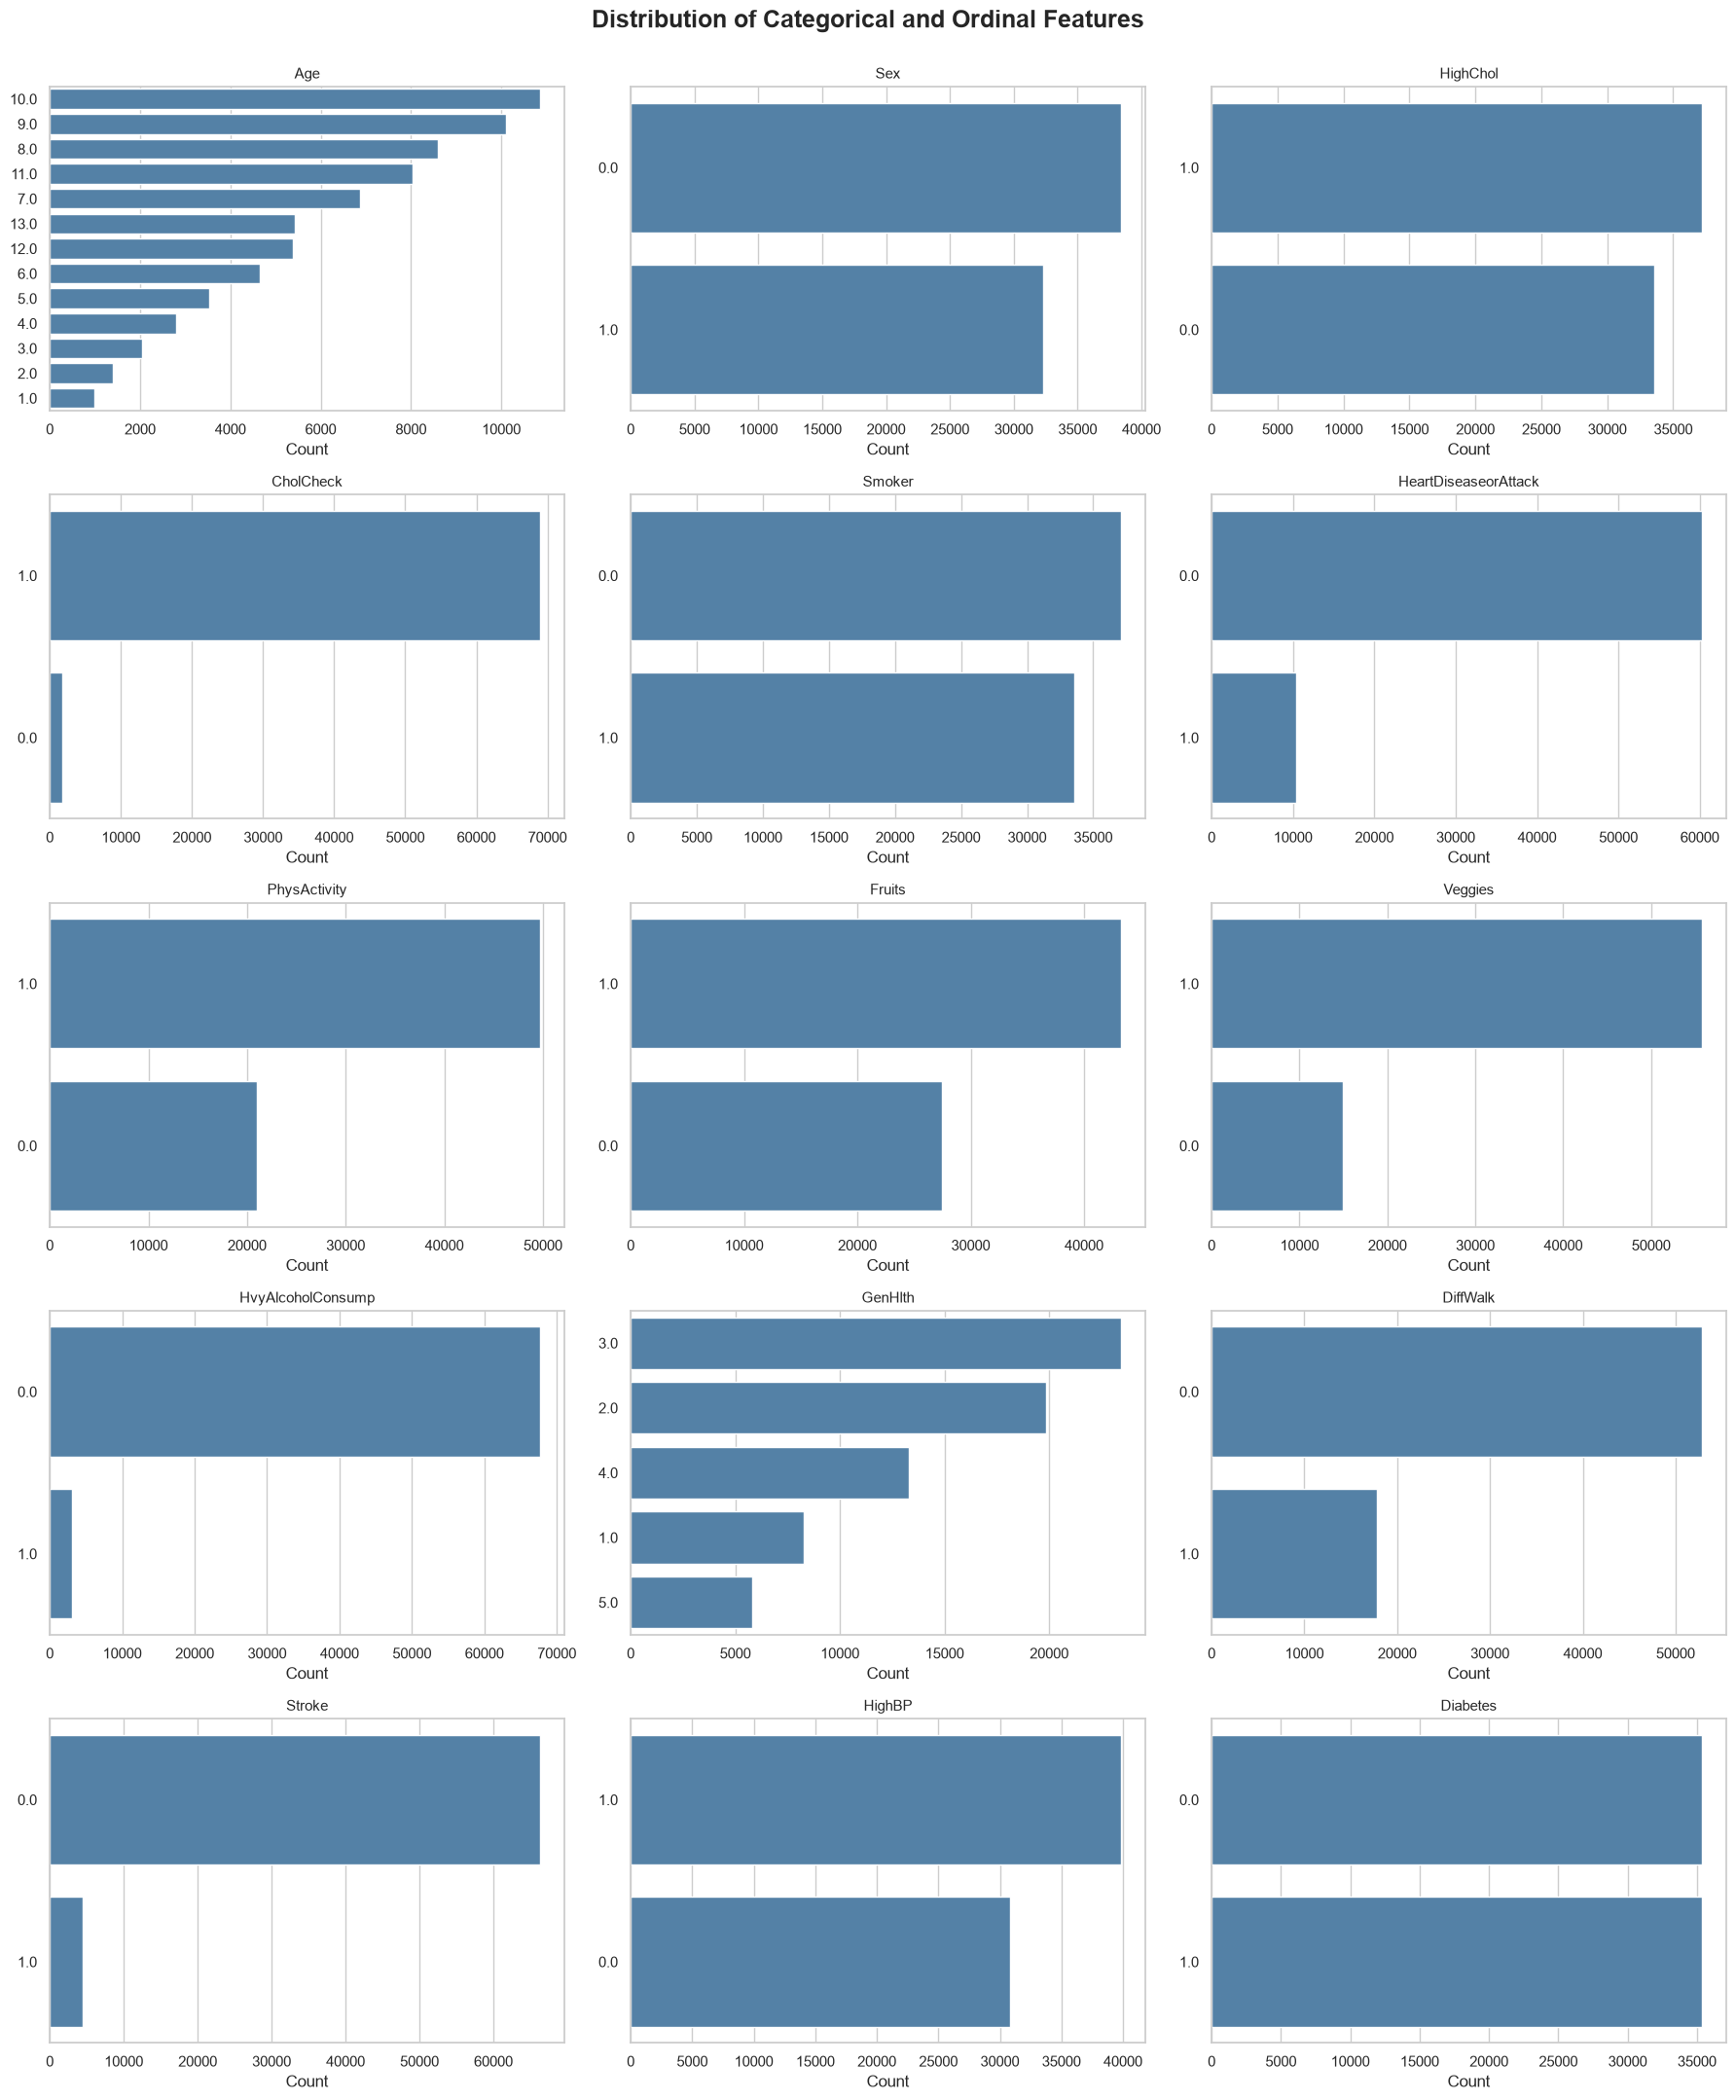

In [ ]:
# 01
# Visualize Categorical and Ordinal Feature Distributions

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

fig, axes = plt.subplots(5, 3, figsize=(18, 22))
axes = axes.flatten()

for ax, feature in zip(axes, categorical_features):

    sns.countplot(
        data=df,
        y=feature,
        order=df[feature].value_counts().index,
        color="#4682B4", #this looks cleaner
        ax=ax
    )

    ax.set_title(feature, fontsize=11)
    ax.set_xlabel("Count")
    ax.set_ylabel("")

# Remove unused subplot
for ax in axes[len(categorical_features):]:
    fig.delaxes(ax)

plt.suptitle(
    "Distribution of Categorical and Ordinal Features",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

findfont: Failed to find font weight semibold, now using 700.


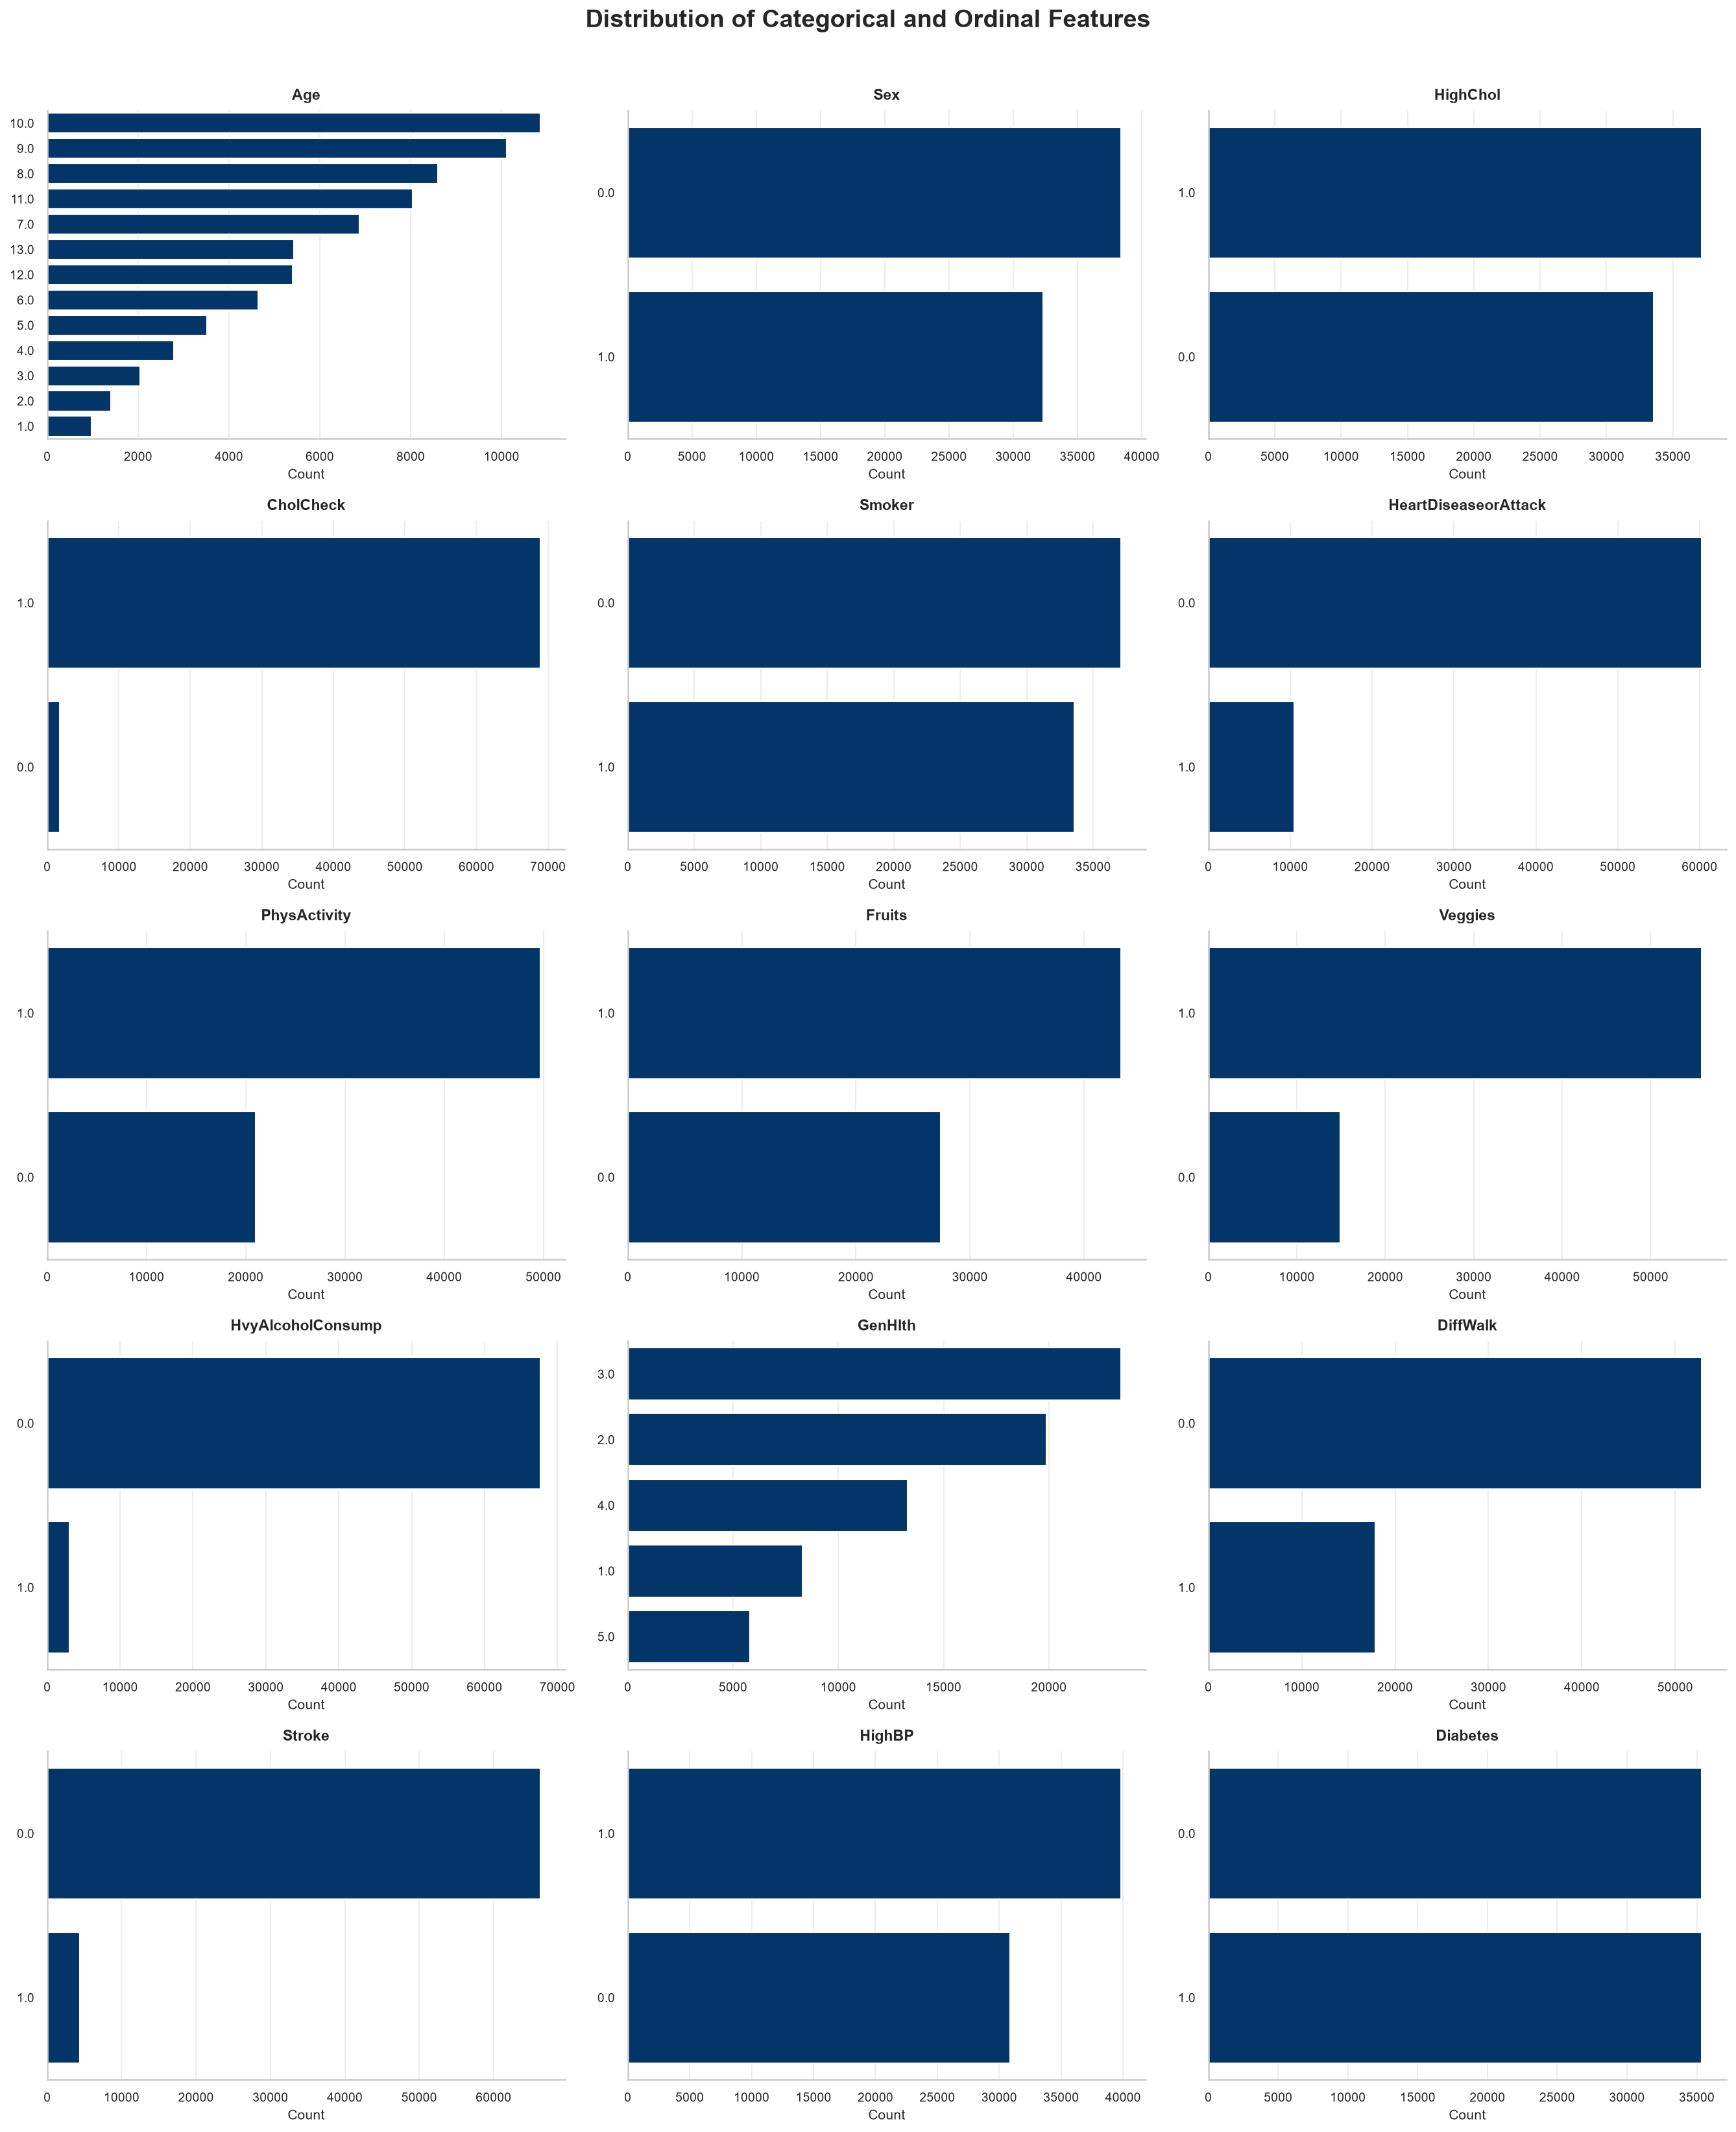

In [ ]:
#01 final
# # Visualize Categorical and Ordinal Feature Distributions

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

fig, axes = plt.subplots(5, 3, figsize=(18, 22), dpi=150)
axes = axes.flatten()

for ax, feature in zip(axes, categorical_features):

    sns.countplot(
        data=df,
        y=feature,
        order=df[feature].value_counts().index,
        color="#00356B",   #ivy league
        #color="#4C78A8",    #my og
        #color="#4682B4",    #this looks cleaner
        saturation=0.95,
        ax=ax
    )

    ax.set_title(
        feature,
        fontsize=11,
        fontweight="semibold",
        pad=8
    )

    ax.set_xlabel("Count", fontsize=10)
    ax.set_ylabel("")

    # Cleaner grid
    ax.grid(axis="x", alpha=0.35)
    ax.grid(axis="y", visible=False)

    # Remove unnecessary borders
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Consistent tick size
    ax.tick_params(labelsize=9)

# Remove unused subplot
for ax in axes[len(categorical_features):]:
    fig.delaxes(ax)

plt.suptitle(
    "Distribution of Categorical and Ordinal Features",
    fontsize=18,
    fontweight="bold",
    y=0.995
)

plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.show()

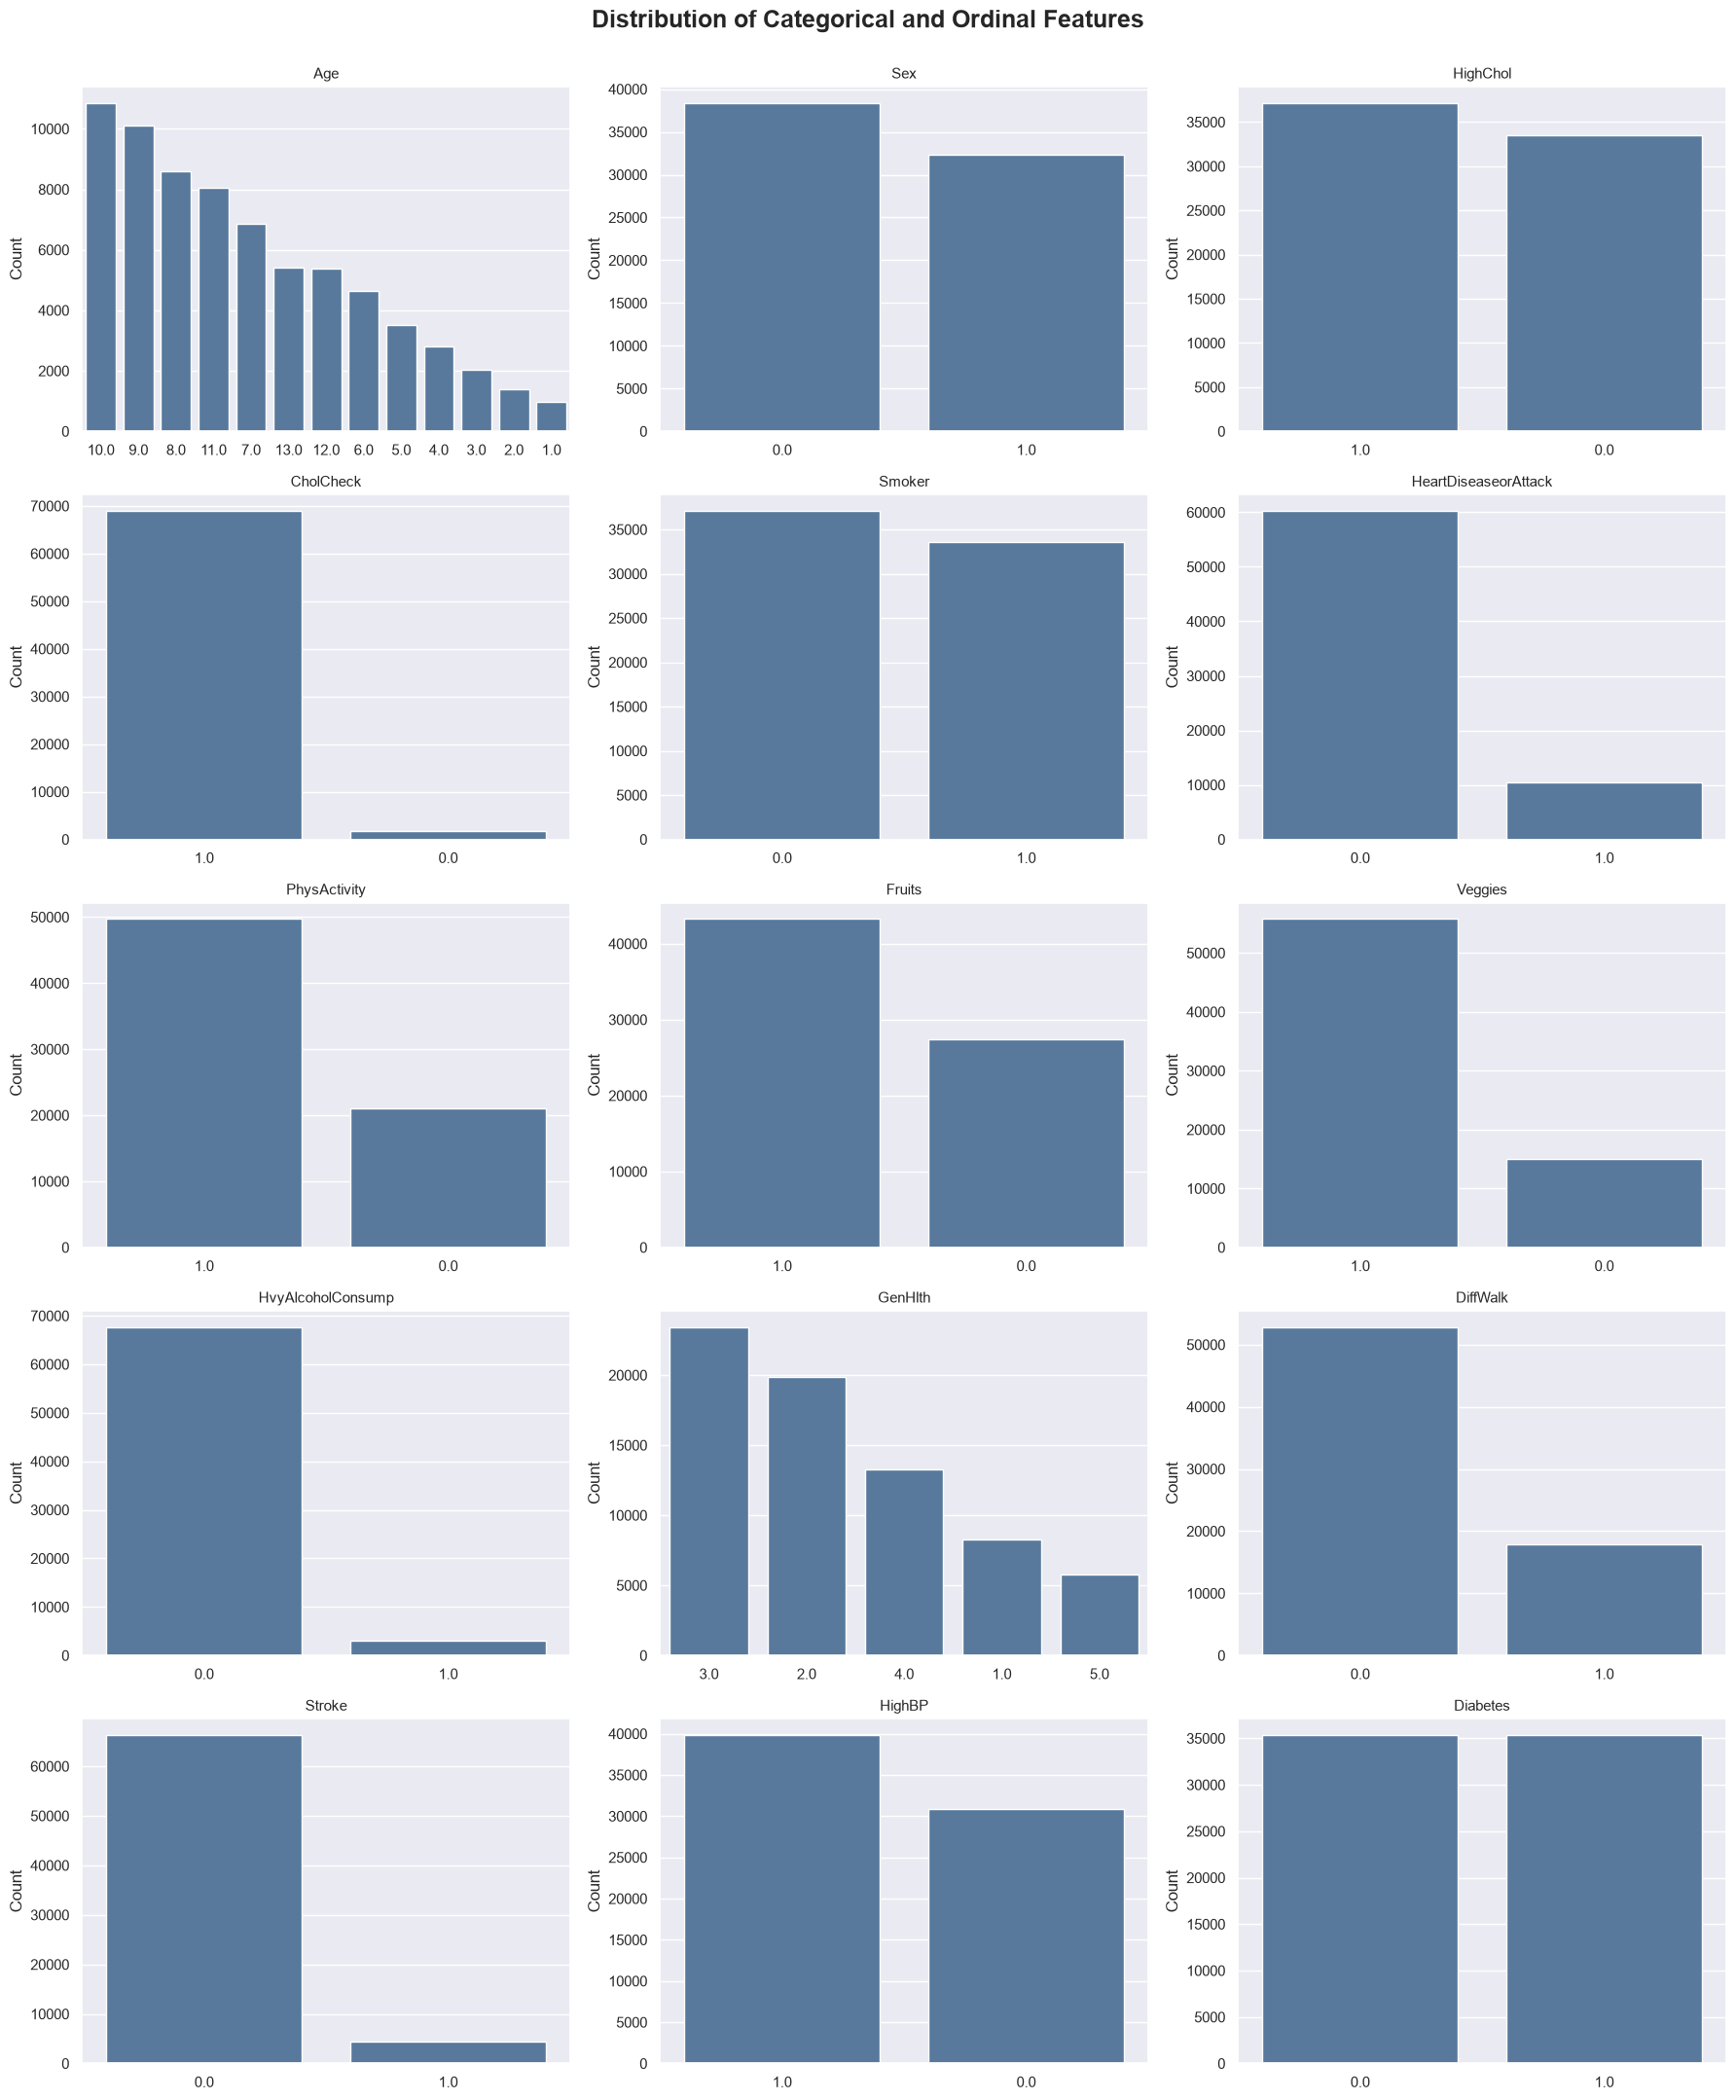

In [ ]:
#01 flip
# Visualize Categorical and Ordinal Feature Distributions

sns.set_theme(
    style="darkgrid",
    context="notebook"
)

fig, axes = plt.subplots(5, 3, figsize=(18, 22))
axes = axes.flatten()

for ax, feature in zip(axes, categorical_features):

    sns.countplot(
        data=df,
        x=feature,
        order=df[feature].value_counts().index,
        color="#4C78A8",
        ax=ax
    )

    ax.set_title(feature, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("Count")

# Remove unused subplot
for ax in axes[len(categorical_features):]:
    fig.delaxes(ax)

plt.suptitle(
    "Distribution of Categorical and Ordinal Features",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

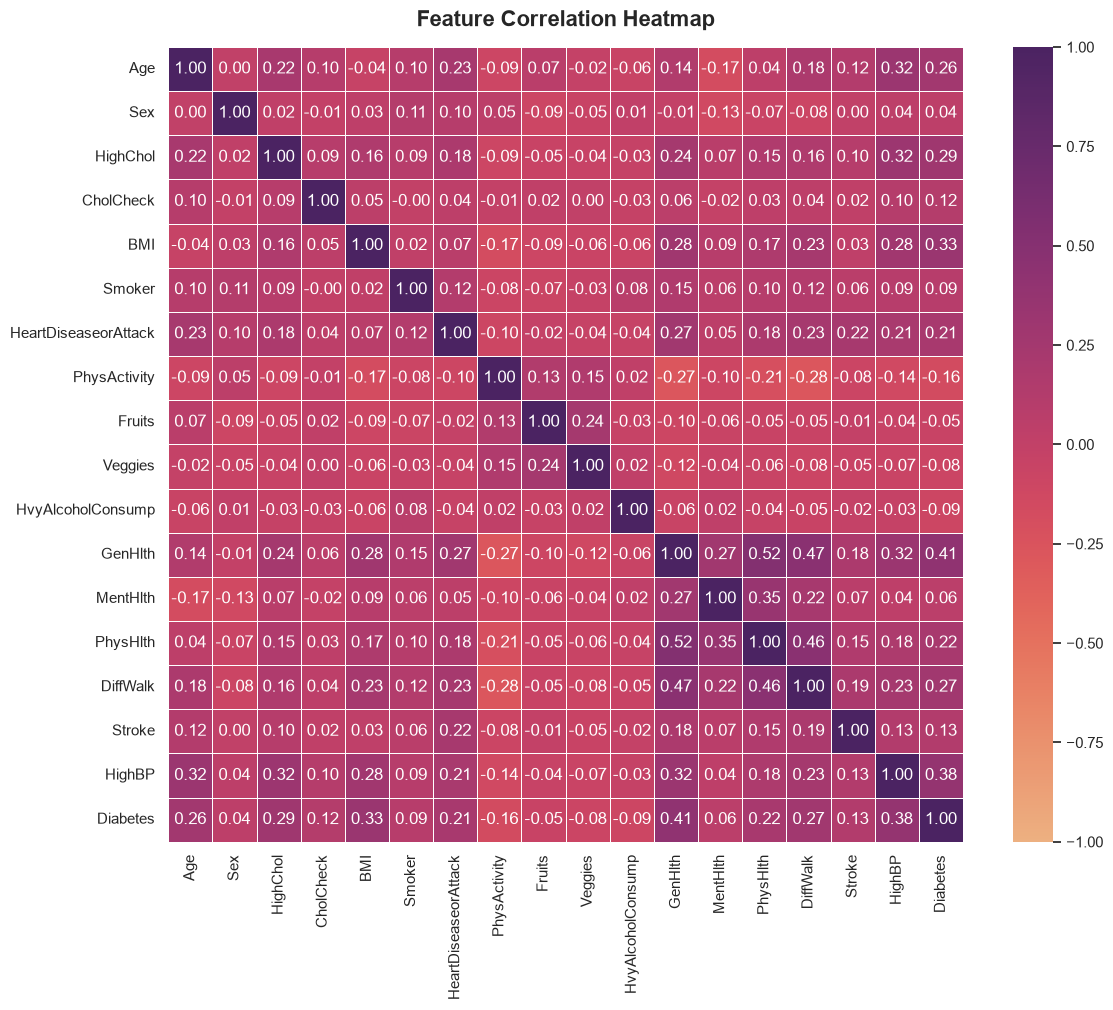

In [ ]:
#og Analyze Feature Correlation Heatmap (Spearman Correlation)

plt.figure(figsize=(12, 10))

correlation_matrix = df.corr(method="spearman")

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="flare",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap", fontsize=16, fontweight="bold", pad=15)

plt.tight_layout()
plt.show()


#plt.figure(figsize=(12,12),dpi=150) #Dots Per Inch
#sns.heatmap(df.corr(method='spearman'),vmin=0,fmt='.1f',annot=True,cmap='flare')

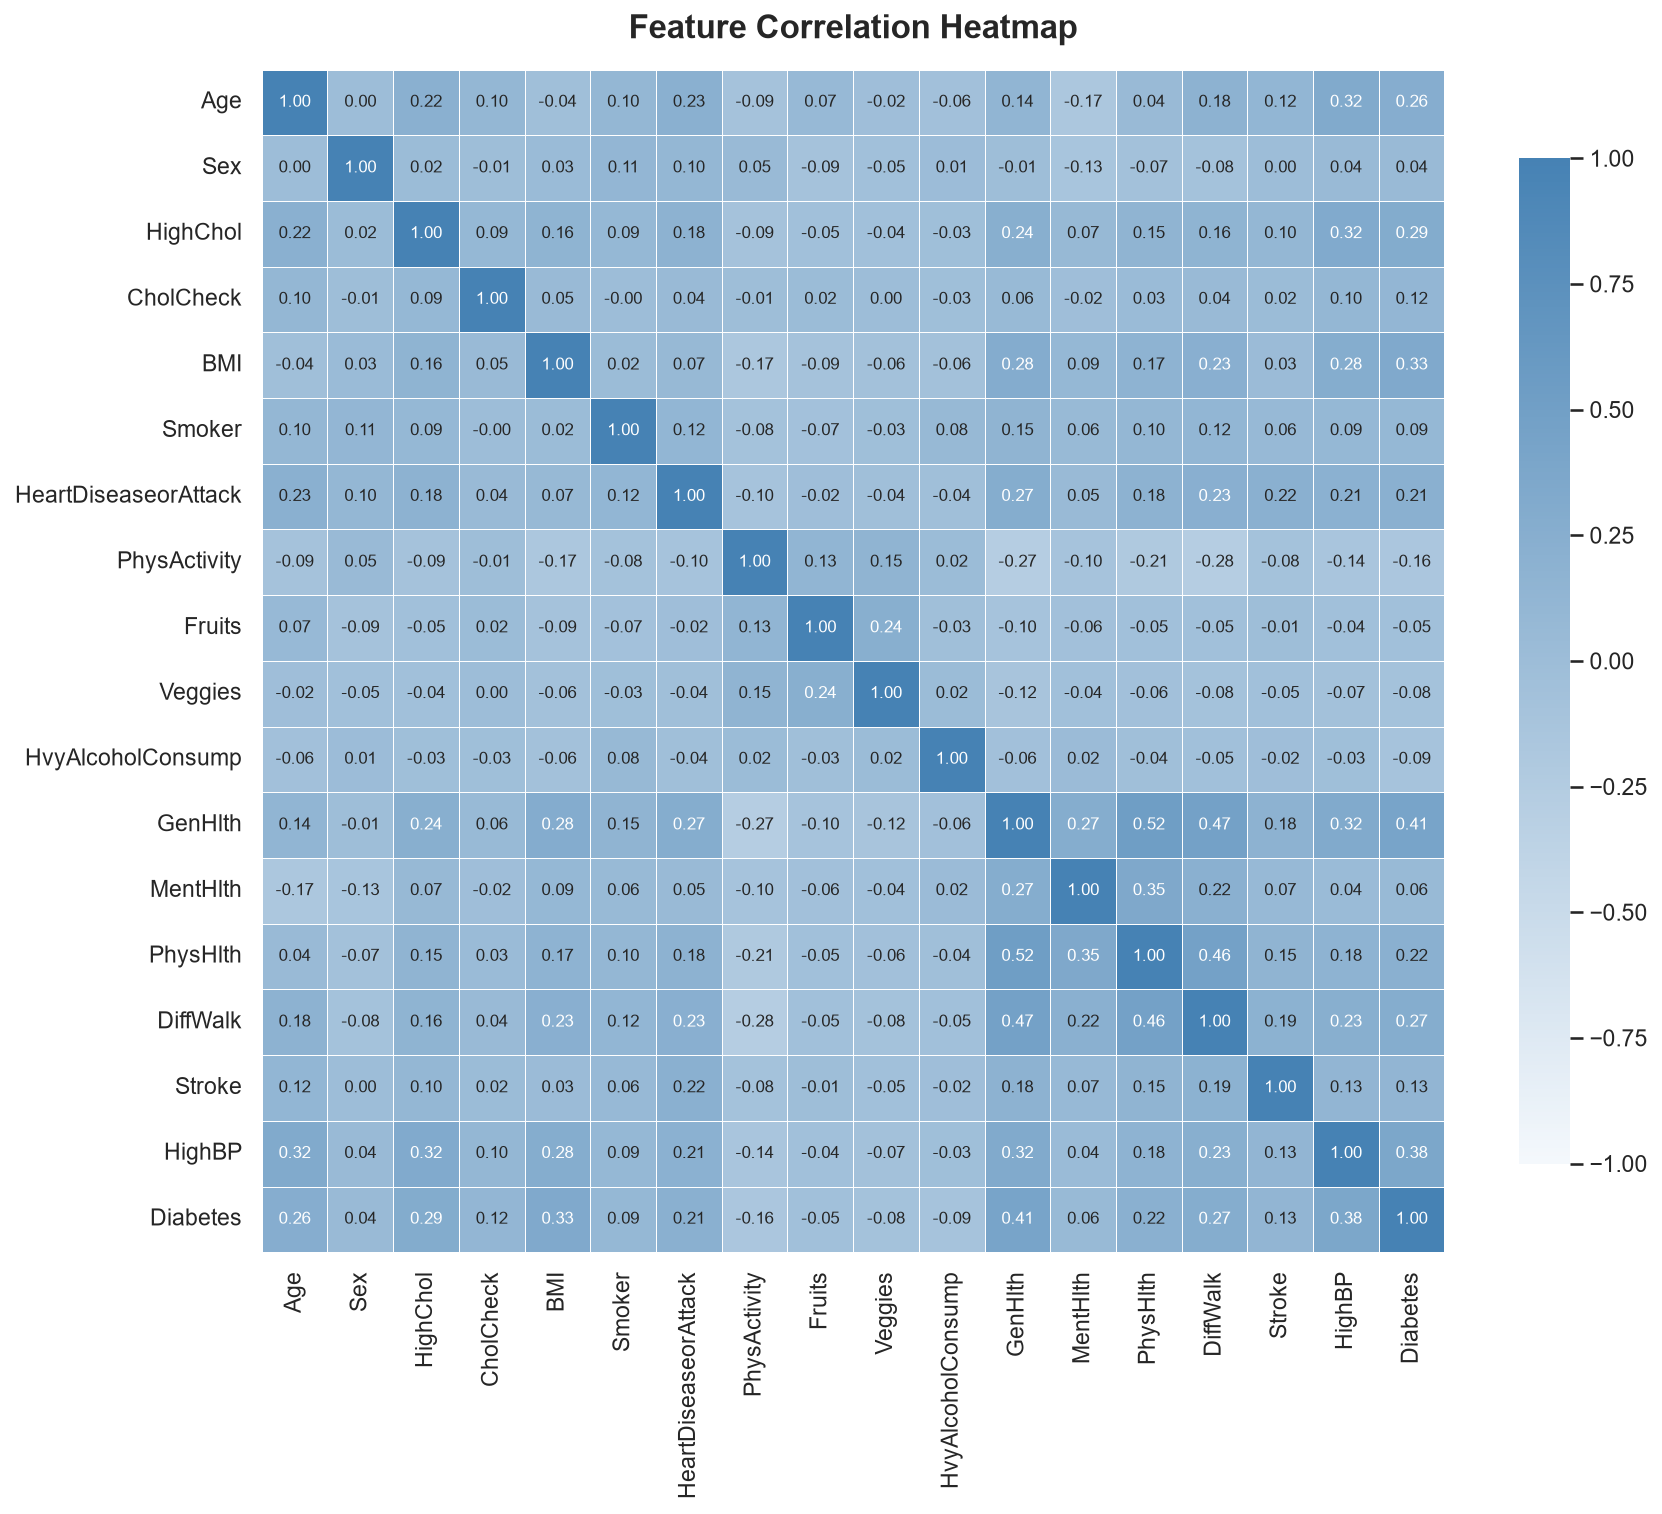

In [ ]:
# Analyze Feature Correlation Heatmap (Spearman Correlation)

from matplotlib.colors import LinearSegmentedColormap

# Custom Ivy League color palette
steel_cmap = LinearSegmentedColormap.from_list(
    "steel_blue",
    ["#F4F8FC", "#4682B4"]
)

plt.figure(figsize=(12, 10), dpi=150)

correlation_matrix = df.corr(method="spearman")

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap=steel_cmap,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.3,
    linecolor="white",
    annot_kws={"size": 8},
    cbar_kws={"shrink": 0.85}
)

plt.title(
    "Feature Correlation Heatmap",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.show()

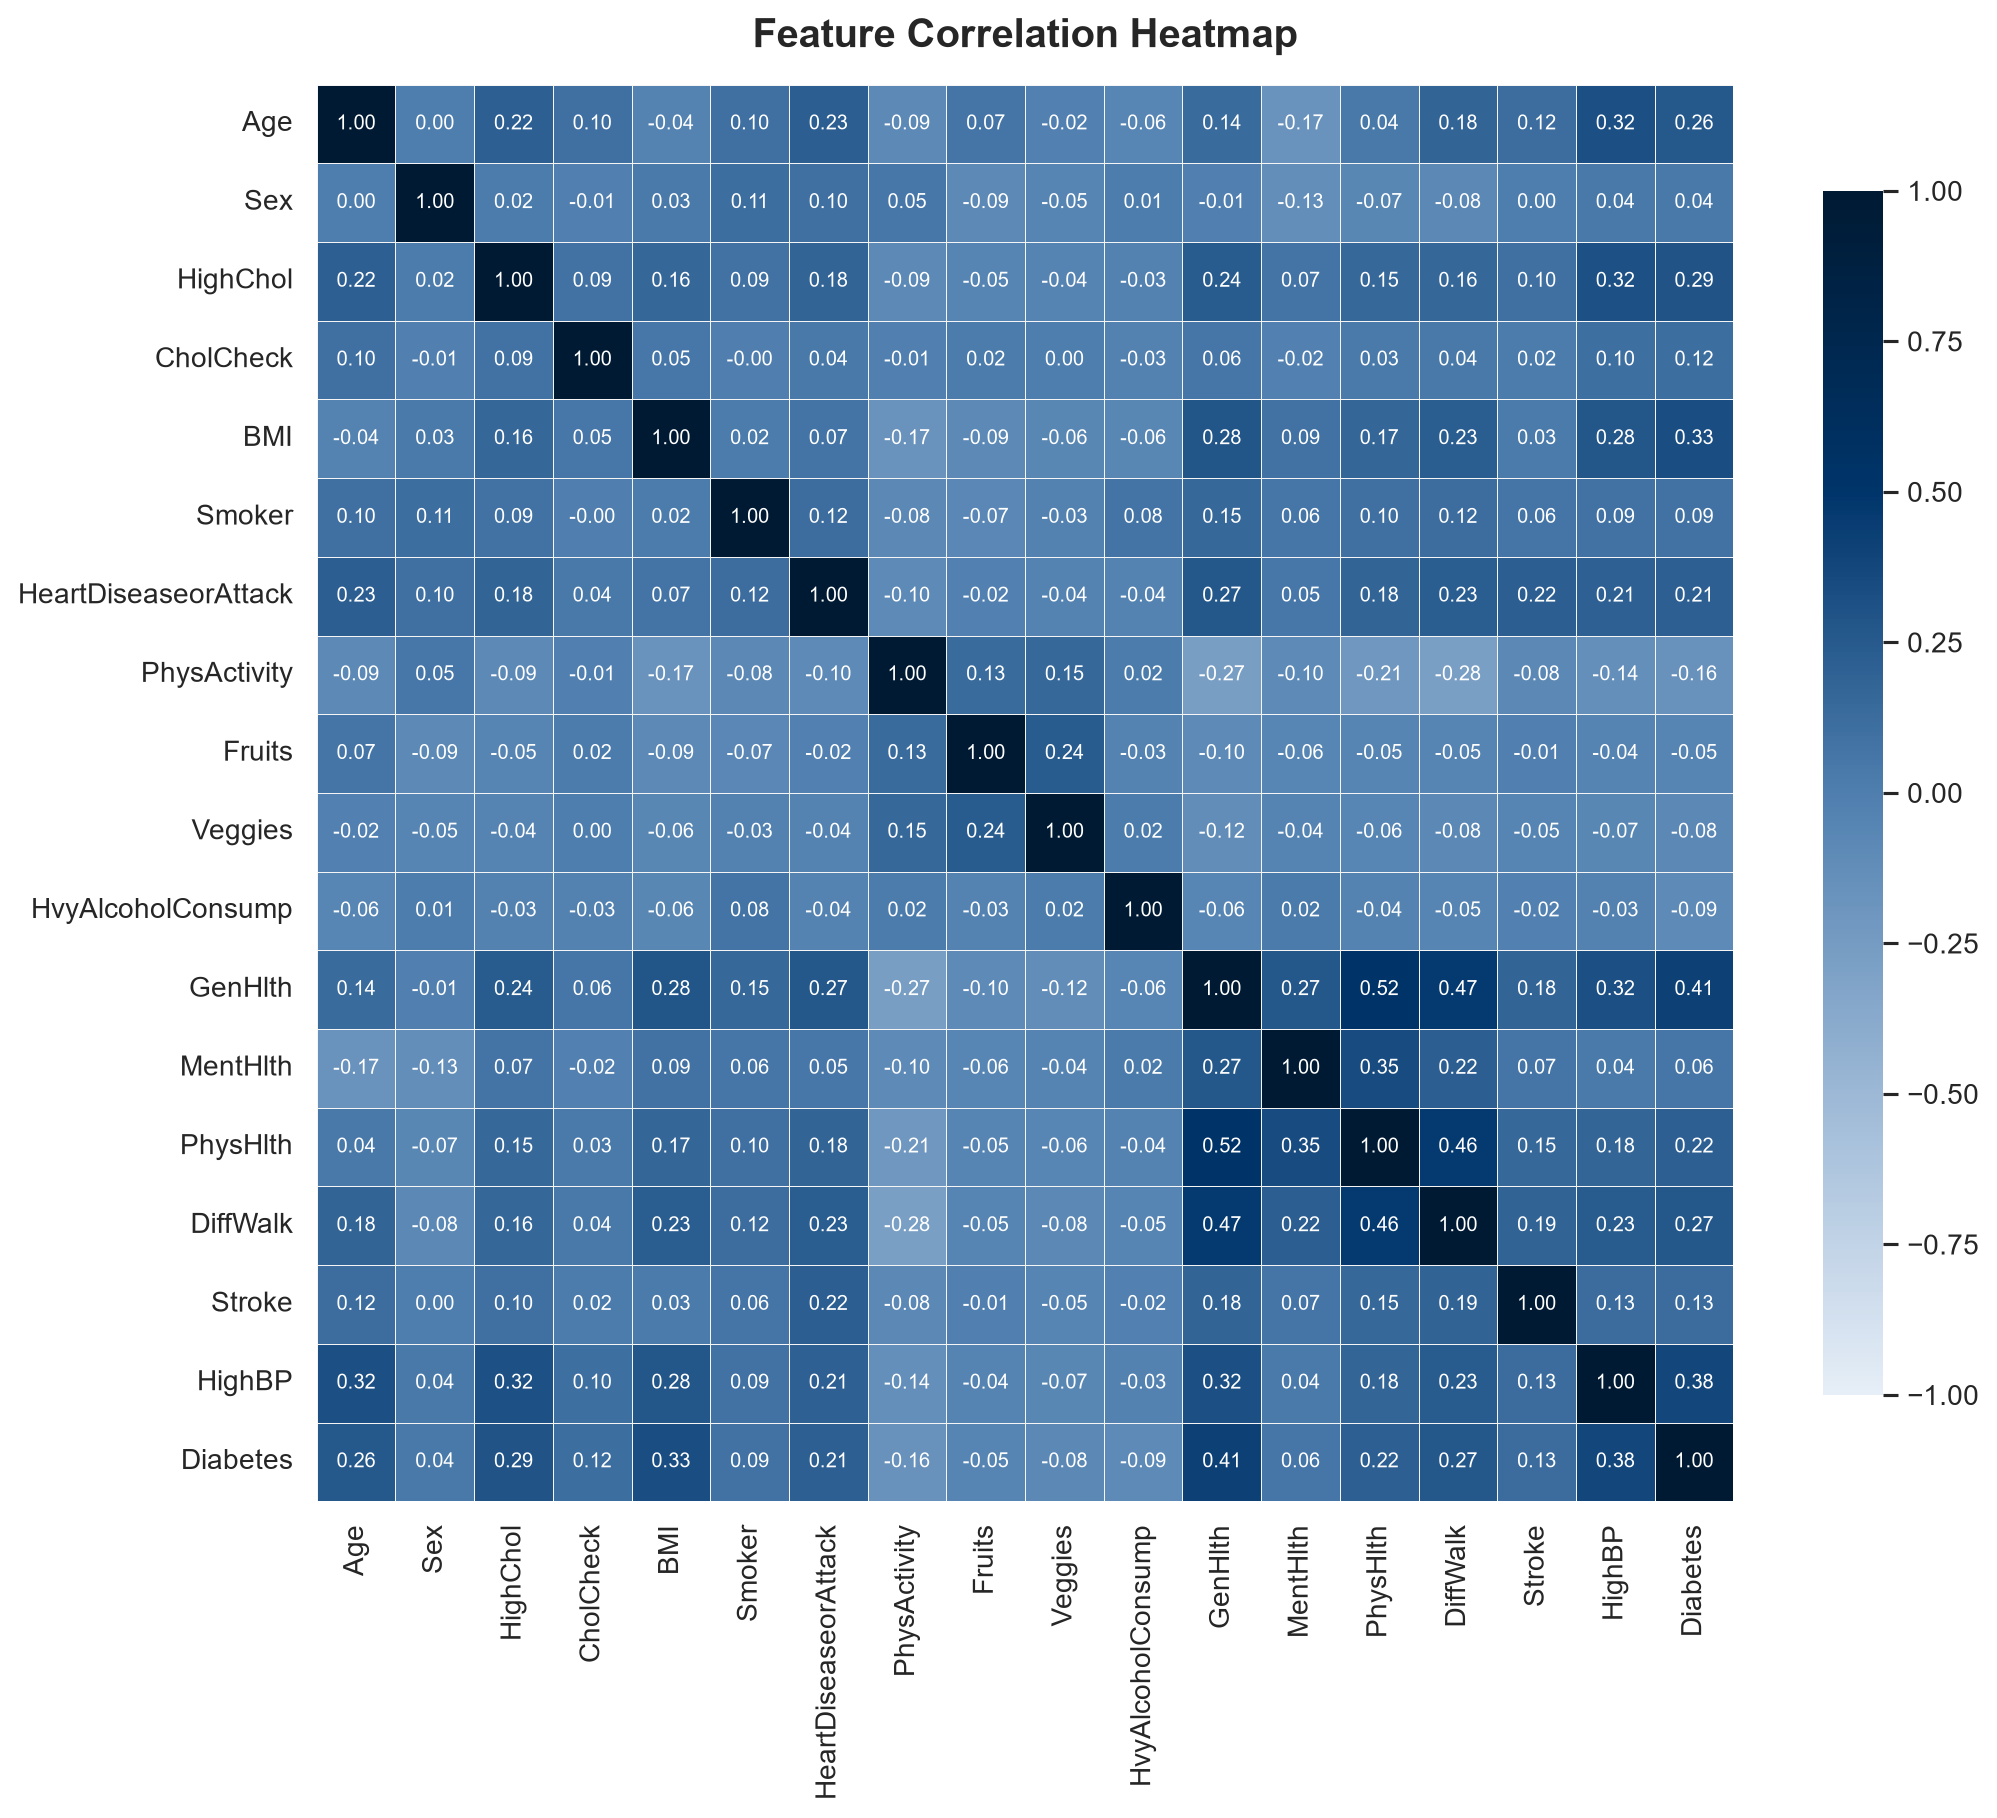

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

ivy_cmap = LinearSegmentedColormap.from_list(
    "ivy_blue",
    [
        "#E6EEF7",
        "#9CB8D6",
        "#4F7FAF",
        "#00356B",
        "#001A33"
    ]
)

plt.figure(figsize=(12, 10), dpi=180)

correlation_matrix = df.corr(method="spearman")

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap=ivy_cmap,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.25,
    linecolor="#F5F5F5",
    annot_kws={"size": 8},
    cbar_kws={"shrink": 0.85}
)

plt.title(
    "Feature Correlation Heatmap",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.show()

# 4. Disease-specific Prediction Pipelines

Each disease is treated as an independent binary classification task following a standardized machine learning workflow. For every disease prediction pipeline, the following steps are performed:

- Data preparation and feature scaling
- Model training using multiple machine learning algorithms
- Model evaluation using performance metrics
- Selection of the best-performing model for comparison

## 4.1 Stroke Prediction

### Data Preparation

In [ ]:
# Split Features (X) and Target Variable (y)

X = df.drop("Stroke", axis=1)
y = df["Stroke"]

print("Feature Matrix Shape:", X.shape)
print("Target Vector Shape:", y.shape, "\n")



# Split the Dataset into Training and Testing Sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=105,
    stratify=y
)



# Display the Dimensions of the Training and Testing Sets

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Feature Matrix Shape: (70692, 17)
Target Vector Shape: (70692,) 

Training Features : (49484, 17)
Testing Features  : (21208, 17)
Training Labels   : (49484,)
Testing Labels    : (21208,)


In [ ]:
# Feature Scaling

scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [ ]:
'''# Verify Class Distribution After Stratified Split

print("\nTraining Set Class Distribution:")
display(y_train.value_counts(normalize=True).round(3).rename("Proportion"))

print("\nTesting Set Class Distribution:")
display(y_test.value_counts(normalize=True).round(3).rename("Proportion"))'''

'# Verify Class Distribution After Stratified Split\n\nprint("\nTraining Set Class Distribution:")\ndisplay(y_train.value_counts(normalize=True).round(3).rename("Proportion"))\n\nprint("\nTesting Set Class Distribution:")\ndisplay(y_test.value_counts(normalize=True).round(3).rename("Proportion"))'

### Shared Model Utilities

In [ ]:
# Initialize Model Accuracy Storage

model_accuracies = {
    "Stroke": {},
    "Diabetes": {},
    "Hypertension": {}
}

In [ ]:
# Train, Evaluate, and Compare Machine Learning Models

def model_train_test(disease, model_name, model):

    # Train the model
    model.fit(X_train_scaled, y_train)

    # Make predictions
    y_pred = model.predict(X_test_scaled)

    # Display classification report
    print(classification_report(y_test, y_pred))

    # Generate confusion matrix
    cm = metrics.confusion_matrix(y_test, y_pred)

    # Plot confusion matrix
    fig, ax = plot_confusion_matrix(
        conf_mat=cm,
        figsize=(8, 8),
        cmap="flare"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    # Calculate accuracy
    accuracy = metrics.accuracy_score(y_test, y_pred) * 100

    # Store accuracy
    model_accuracies[disease][model_name] = accuracy

    print(f"Accuracy: {accuracy:.2f}%\n")

    # ROC Curve
    RocCurveDisplay.from_estimator(
        model,
        X_test_scaled,
        y_test
    )

    plt.title(f"{model_name} - ROC Curve")
    plt.show()

In [ ]:
'''#og Train, Evaluate, and Compare Machine Learning Models

def model_train_test(disease, model_name, model):

    # Train the model
    model.fit(X_train_scaled, y_train)

    # Make predictions
    y_pred = model.predict(X_test_scaled)

    # Calculate accuracy
    accuracy = metrics.accuracy_score(y_test, y_pred) * 100

    # Store accuracy
    model_accuracies[disease][model_name] = accuracy

    print(f"Accuracy: {accuracy:.2f}%\n")

    # Display classification report
    print(classification_report(y_test, y_pred))

    # Create side-by-side plots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Confusion Matrix
    cm = metrics.confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="flare",
        cbar=False,
        square=True,
        ax=axes[0]
    )

    axes[0].set_title(f"{model_name} - Confusion Matrix")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")

    # ROC Curve
    RocCurveDisplay.from_estimator(
        model,
        X_test_scaled,
        y_test,
        ax=axes[1]
    )

    axes[1].set_title(f"{model_name} - ROC Curve")

    plt.tight_layout()
    plt.show()
    '''

'#og Train, Evaluate, and Compare Machine Learning Models\n\ndef model_train_test(disease, model_name, model):\n\n    # Train the model\n    model.fit(X_train_scaled, y_train)\n\n    # Make predictions\n    y_pred = model.predict(X_test_scaled)\n\n    # Calculate accuracy\n    accuracy = metrics.accuracy_score(y_test, y_pred) * 100\n\n    # Store accuracy\n    model_accuracies[disease][model_name] = accuracy\n\n    print(f"Accuracy: {accuracy:.2f}%\n")\n\n    # Display classification report\n    print(classification_report(y_test, y_pred))\n\n    # Create side-by-side plots\n    fig, axes = plt.subplots(1, 2, figsize=(14, 5))\n\n    # Confusion Matrix\n    cm = metrics.confusion_matrix(y_test, y_pred)\n\n    sns.heatmap(\n        cm,\n        annot=True,\n        fmt="d",\n        cmap="flare",\n        cbar=False,\n        square=True,\n        ax=axes[0]\n    )\n\n    axes[0].set_title(f"{model_name} - Confusion Matrix")\n    axes[0].set_xlabel("Predicted")\n    axes[0].set_ylabel("A

In [ ]:
'''# Train, Evaluate, and Compare Machine Learning Models

def model_train_test(disease, model_name, model):

    # Train the model
    model.fit(X_train_scaled, y_train)

    # Make predictions
    y_pred = model.predict(X_test_scaled)

    # Display classification report
    print(classification_report(y_test, y_pred))

    # Calculate accuracy
    accuracy = metrics.accuracy_score(y_test, y_pred) * 100
    model_accuracies[disease][model_name] = accuracy

    print(f"Accuracy: {accuracy:.2f}%\n")

    # Create side-by-side plots
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 4.2),
        dpi=150,
        gridspec_kw={"width_ratios": [1, 1]}
    )

    # =========================
    # Confusion Matrix
    # =========================

    cm = metrics.confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=sns.light_palette("#00356B", as_cmap=True),
        cbar=False,
        square=True,
        linewidths=0.5,
        linecolor="white",
        annot_kws={
            "fontsize":10,
            "fontweight":"semibold"
        },
        ax=axes[0]
    )

    axes[0].set_title(
        f"{model_name} - Confusion Matrix",
        fontsize=12,
        fontweight="bold",
        pad=10
    )

    axes[0].set_xlabel("Predicted", fontsize=10)
    axes[0].set_ylabel("Actual", fontsize=10)

    axes[0].tick_params(labelsize=9)

    # =========================
    # ROC Curve
    # =========================

    RocCurveDisplay.from_estimator(
        model,
        X_test_scaled,
        y_test,
        ax=axes[1]
    )

    # Style ROC curve
    axes[1].lines[0].set_color("#00356B")
    axes[1].lines[0].set_linewidth(2.5)

    # Random classifier reference
    axes[1].plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        color="gray",
        linewidth=1.2
    )

    axes[1].grid(alpha=0.3)

    axes[1].set_title(
        f"{model_name} - ROC Curve",
        fontsize=12,
        fontweight="bold",
        pad=10
    )

    # Cleaner axis labels
    axes[1].set_xlabel("False Positive Rate", fontsize=10)
    axes[1].set_ylabel("True Positive Rate", fontsize=10)

    axes[1].tick_params(labelsize=9)

    # Smaller legend
    axes[1].legend(fontsize=9)

    # Better spacing than tight_layout()
    plt.subplots_adjust(
        left=0.08,
        right=0.96,
        top=0.86,
        bottom=0.15,
        wspace=0.35
    )

    plt.show()'''

'# Train, Evaluate, and Compare Machine Learning Models\n\ndef model_train_test(disease, model_name, model):\n\n    # Train the model\n    model.fit(X_train_scaled, y_train)\n\n    # Make predictions\n    y_pred = model.predict(X_test_scaled)\n\n    # Display classification report\n    print(classification_report(y_test, y_pred))\n\n    # Calculate accuracy\n    accuracy = metrics.accuracy_score(y_test, y_pred) * 100\n    model_accuracies[disease][model_name] = accuracy\n\n    print(f"Accuracy: {accuracy:.2f}%\n")\n\n    # Create side-by-side plots\n    fig, axes = plt.subplots(\n        1,\n        2,\n        figsize=(14, 4.2),\n        dpi=150,\n        gridspec_kw={"width_ratios": [1, 1]}\n    )\n\n    # =========================\n    # Confusion Matrix\n    # =========================\n\n    cm = metrics.confusion_matrix(y_test, y_pred)\n\n    sns.heatmap(\n        cm,\n        annot=True,\n        fmt="d",\n        cmap=sns.light_palette("#00356B", as_cmap=True),\n        cbar=Fa

In [ ]:
# Plot Model Accuracy Comparison

def plot_bar(disease):

    models = list(model_accuracies[disease].keys())
    accuracies = list(model_accuracies[disease].values())

    plt.figure(figsize=(10, 6))

    plt.bar(
        models,
        accuracies,
        color=sns.color_palette("flare", len(models))
    )

    plt.title(f"{disease} - Model Accuracy Comparison", fontsize=14, fontweight="bold")
    plt.xlabel("Machine Learning Models")
    plt.ylabel("Accuracy (%)")
    plt.ylim(0, 100)

    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

### Model Training

**LOGISTIC REGRESSION**

In [ ]:
# Logistic Regression with Hyperparameter Tuning

param_grid = {
    "C": np.logspace(-3, 3, 7),
    "penalty": ["l1", "l2"]
}

logistic_model = GridSearchCV(
    estimator=LogisticRegression(
        solver="liblinear",
        random_state=42,
        class_weight="balanced"
    ),
    param_grid=param_grid,
    cv=10,
    scoring="accuracy",
    n_jobs=-1
)

model_train_test(
    disease="Stroke",
    model_name="Logistic Regression",
    model=logistic_model
)

c:\Users\USER\.pyenv\pyenv-win\versions\3.12.10\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\USER\.pyenv\pyenv-win\versions\3.12.10\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


              precision    recall  f1-score   support

         0.0       0.98      0.73      0.84     19889
         1.0       0.15      0.73      0.25      1319

    accuracy                           0.73     21208
   macro avg       0.56      0.73      0.55     21208
weighted avg       0.93      0.73      0.80     21208



NameError: name 'plot_confusion_matrix' is not defined

**GAUSSIAN NAIVE BAYES**

Accuracy: 82.09%

              precision    recall  f1-score   support

         0.0       0.96      0.84      0.90     19889
         1.0       0.18      0.54      0.27      1319

    accuracy                           0.82     21208
   macro avg       0.57      0.69      0.59     21208
weighted avg       0.92      0.82      0.86     21208



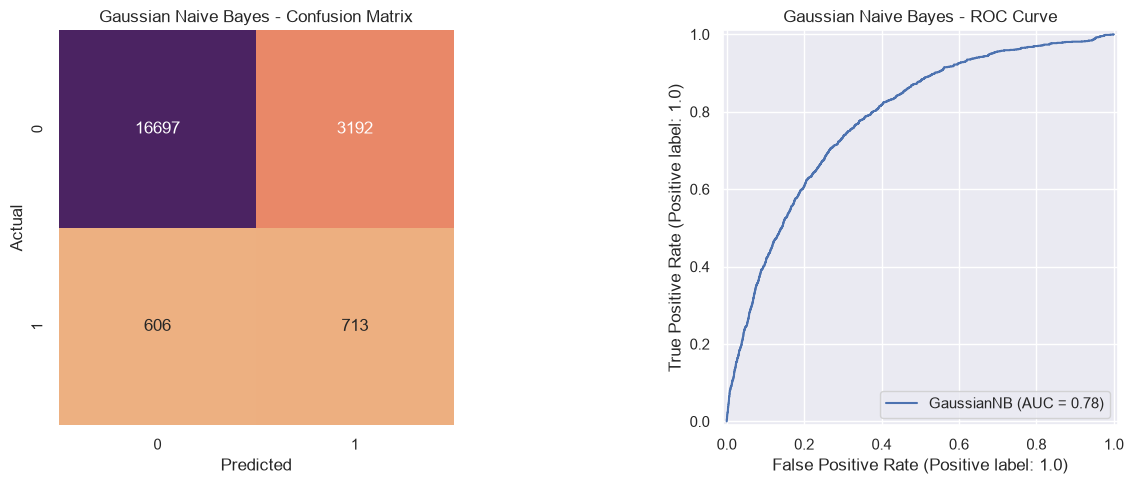

In [ ]:
# Gaussian Naive Bayes

gaussian_nb = GaussianNB()

model_train_test(
    disease="Stroke",
    model_name="Gaussian Naive Bayes",
    model=gaussian_nb
)

**BERNOULLI NAIVE BAYES**

Accuracy: 88.02%

              precision    recall  f1-score   support

         0.0       0.96      0.91      0.93     19889
         1.0       0.22      0.37      0.28      1319

    accuracy                           0.88     21208
   macro avg       0.59      0.64      0.61     21208
weighted avg       0.91      0.88      0.89     21208



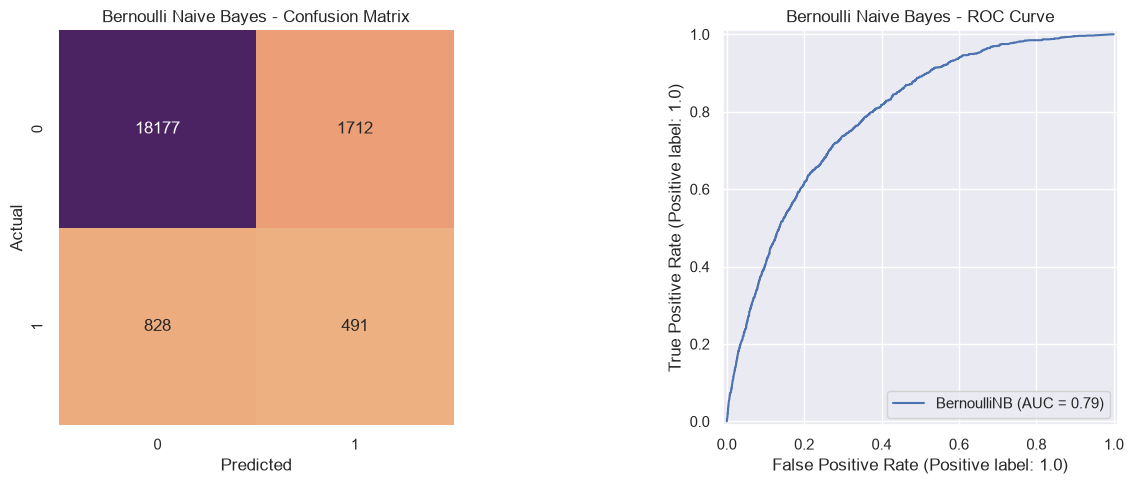

In [ ]:
# Bernoulli Naive Bayes

bernoulli_nb = BernoulliNB()

model_train_test(
    disease="Stroke",
    model_name="Bernoulli Naive Bayes",
    model=bernoulli_nb
)

**K-Nearest Neighbors (KNN)**

In [ ]:
# K-Nearest Neighbors with Hyperparameter Tuning

param_grid = {
    "n_neighbors": range(1, 20)
}

knn_search = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=10,
    scoring="accuracy",
    n_jobs=-1
)

knn_search.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': range(1, 20)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with hig

In [ ]:
# Best Hyperparameter

print("Best Parameters:", knn_search.best_params_)

best_cv_accuracy = knn_search.best_score_ * 100

print(f"Best Cross-Validation Accuracy: {best_cv_accuracy:.2f}%")

Best Parameters: {'n_neighbors': 16}
Best Cross-Validation Accuracy: 93.71%


Accuracy: 93.73%

              precision    recall  f1-score   support

         0.0       0.94      1.00      0.97     19889
         1.0       0.35      0.01      0.02      1319

    accuracy                           0.94     21208
   macro avg       0.64      0.50      0.49     21208
weighted avg       0.90      0.94      0.91     21208



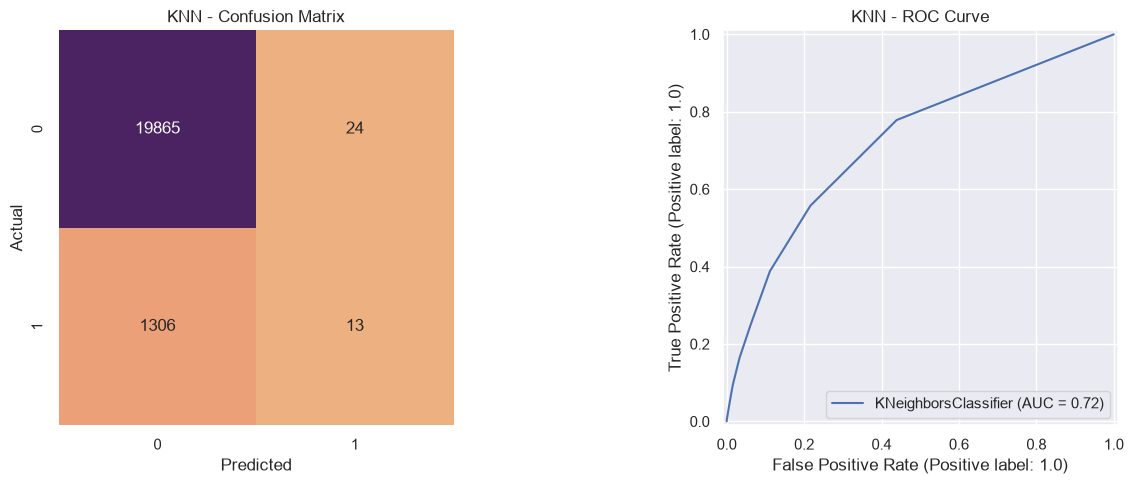

In [ ]:
# K-Nearest Neighbors

best_knn = knn_search.best_estimator_

model_train_test(
    disease="Stroke",
    model_name="KNN",
    model=best_knn
)

**DECISION TREE**

In [ ]:
# Decision Tree with Hyperparameter Tuning

param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [5, 6, 7, 8, 9],
    "max_features": ["sqrt", "log2"],
    "ccp_alpha": [0.1, 0.01, 0.001]
}

decision_tree_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

decision_tree_search.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'ccp_alpha': [0.1, 0.01, ...], 'criterion': ['gini', 'entropy'], 'max_depth': [5, 6, ...], 'max_features': ['sqrt', 'log2']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True


In [ ]:
# Best Hyperparameters

print("Best Parameters:", decision_tree_search.best_params_)

best_cv_accuracy = decision_tree_search.best_score_ * 100

print(f"Best Cross-Validation Accuracy: {best_cv_accuracy:.2f}%")

Best Parameters: {'ccp_alpha': 0.1, 'criterion': 'gini', 'max_depth': 5, 'max_features': 'sqrt'}
Best Cross-Validation Accuracy: 93.78%


Accuracy: 93.78%

              precision    recall  f1-score   support

         0.0       0.94      1.00      0.97     19889
         1.0       0.00      0.00      0.00      1319

    accuracy                           0.94     21208
   macro avg       0.47      0.50      0.48     21208
weighted avg       0.88      0.94      0.91     21208



c:\Users\USER\.pyenv\pyenv-win\versions\3.12.10\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USER\.pyenv\pyenv-win\versions\3.12.10\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USER\.pyenv\pyenv-win\versions\3.12.10\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

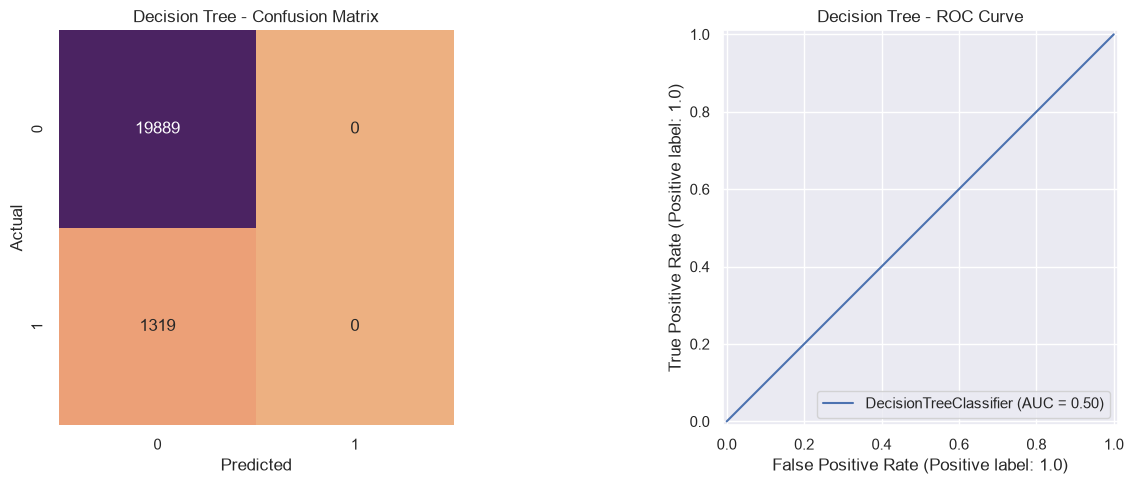

In [ ]:
# Decision Tree

best_decision_tree = decision_tree_search.best_estimator_

model_train_test(
    disease="Stroke",
    model_name="Decision Tree",
    model=best_decision_tree
)

### Model Evaluation

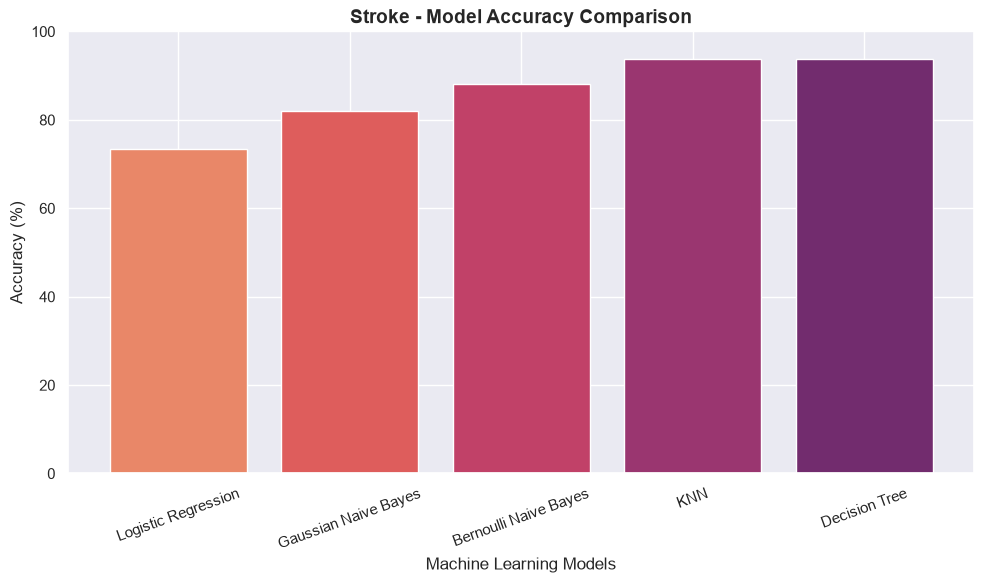

In [ ]:
plot_bar('Stroke')

## 4.2 HyperTension Prediction

### Data Preparation

In [ ]:
# Split Features (X) and Target Variable (y)

X = df.drop("HighBP", axis=1)
y = df["HighBP"]



# Split the Dataset into Training and Testing Sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)



# Display the Dimensions of the Training and Testing Sets

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)



# Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training Features : (49484, 17)
Testing Features  : (21208, 17)
Training Labels   : (49484,)
Testing Labels    : (21208,)


### Model Training

 **LOGISTIC REGRESSION**

c:\Users\USER\.pyenv\pyenv-win\versions\3.12.10\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Accuracy: 73.60%

              precision    recall  f1-score   support

         0.0       0.69      0.71      0.70      9258
         1.0       0.77      0.76      0.76     11950

    accuracy                           0.74     21208
   macro avg       0.73      0.73      0.73     21208
weighted avg       0.74      0.74      0.74     21208



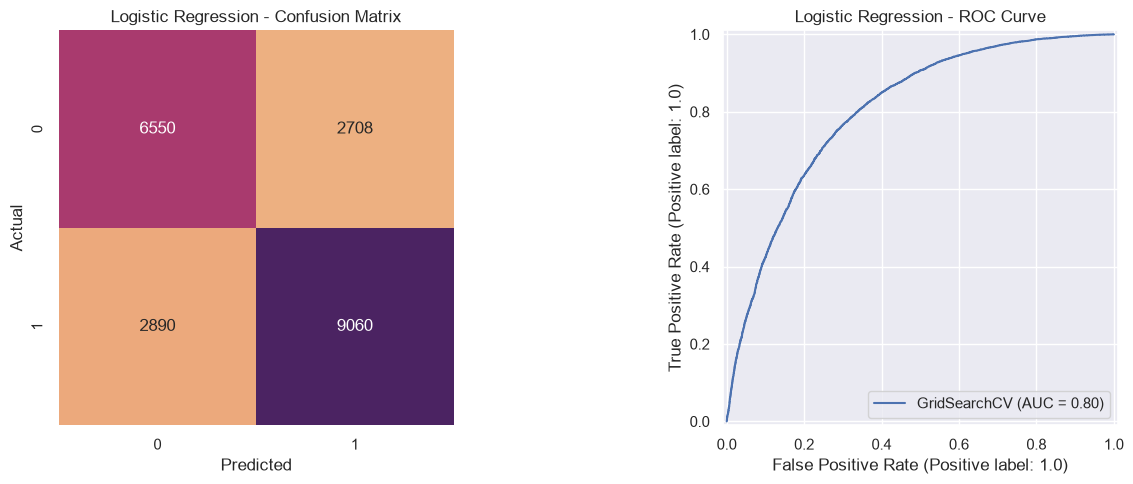

In [ ]:
# Logistic Regression with Hyperparameter Tuning

param_grid = {
    "C": np.logspace(-3, 3, 7),
    "penalty": ["l1", "l2"]
}

logistic_model = GridSearchCV(
    estimator=LogisticRegression(
        class_weight="balanced",
        solver="liblinear",
        random_state=42
    ),
    param_grid=param_grid,
    cv=10,
    scoring="accuracy",
    n_jobs=-1
)

model_train_test(
    disease="Hypertension",
    model_name="Logistic Regression",
    model=logistic_model
)

**GAUSSIAN NAIVE BAYES**

Accuracy: 70.28%

              precision    recall  f1-score   support

         0.0       0.64      0.73      0.68      9258
         1.0       0.76      0.68      0.72     11950

    accuracy                           0.70     21208
   macro avg       0.70      0.71      0.70     21208
weighted avg       0.71      0.70      0.70     21208



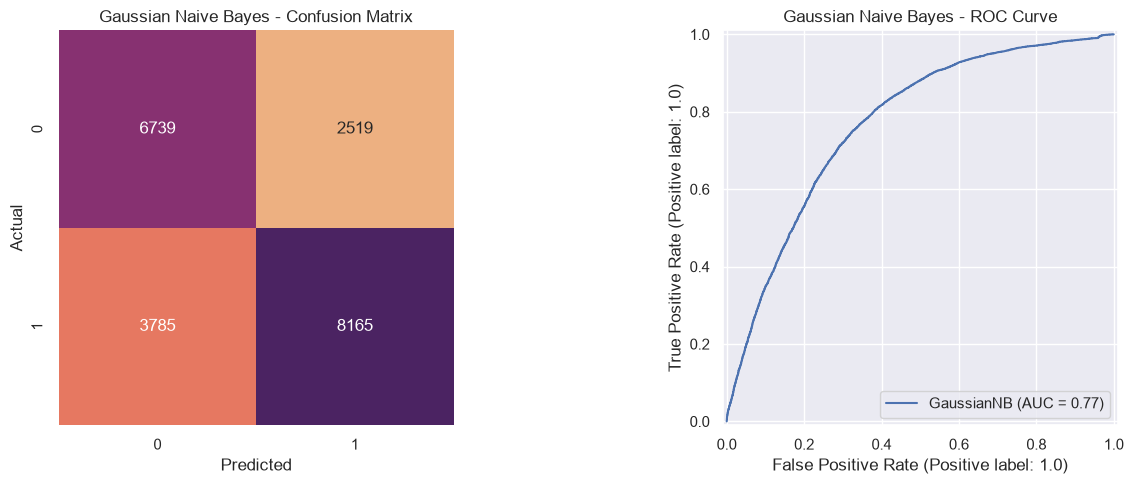

In [ ]:
# Gaussian Naive Bayes

gaussian_nb = GaussianNB()

model_train_test(
    disease="Hypertension",
    model_name="Gaussian Naive Bayes",
    model=gaussian_nb
)

**BERNOULLI NAIVE BAYES**

Accuracy: 71.94%

              precision    recall  f1-score   support

         0.0       0.67      0.69      0.68      9258
         1.0       0.76      0.74      0.75     11950

    accuracy                           0.72     21208
   macro avg       0.72      0.72      0.72     21208
weighted avg       0.72      0.72      0.72     21208



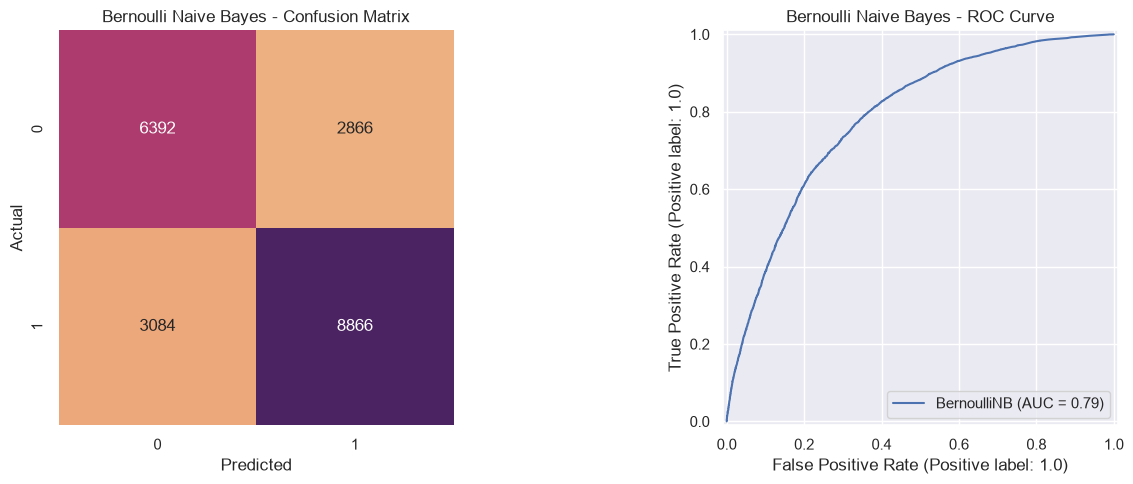

In [ ]:
# Bernoulli Naive Bayes

bernoulli_nb = BernoulliNB()

model_train_test(
    disease="Hypertension",
    model_name="Bernoulli Naive Bayes",
    model=bernoulli_nb
)

**K-Nearest Neighbors (KNN)**

In [ ]:
# K-Nearest Neighbors with Hyperparameter Tuning

param_grid = {
    "n_neighbors": range(1, 20)
}

knn_search = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=10,
    scoring="accuracy",
    n_jobs=-1
)

knn_search.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': range(1, 20)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with hig

In [ ]:
print("Best Parameters:", knn_search.best_params_)

best_cv_accuracy = knn_search.best_score_ * 100

print(f"Best Cross-Validation Accuracy: {best_cv_accuracy:.2f}%")

Best Parameters: {'n_neighbors': 19}
Best Cross-Validation Accuracy: 73.38%


Accuracy: 73.15%

              precision    recall  f1-score   support

         0.0       0.73      0.61      0.67      9258
         1.0       0.73      0.82      0.78     11950

    accuracy                           0.73     21208
   macro avg       0.73      0.72      0.72     21208
weighted avg       0.73      0.73      0.73     21208



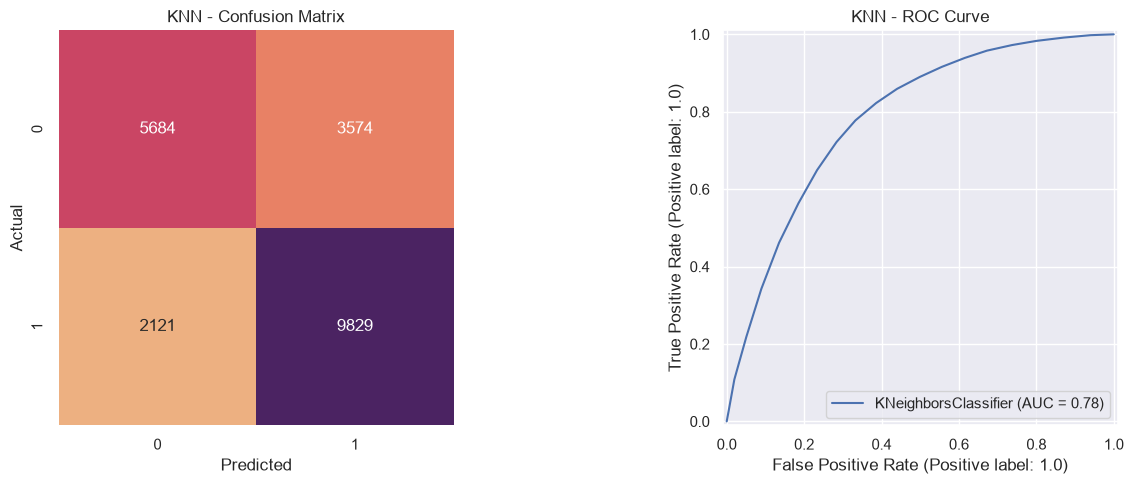

In [ ]:
best_knn = knn_search.best_estimator_

model_train_test(
    disease="Hypertension",
    model_name="KNN",
    model=best_knn
)

**DECISION TREE**

In [ ]:
# Decision Tree with Hyperparameter Tuning

param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [5, 6, 7, 8, 9],
    "max_features": ["sqrt", "log2"],
    "ccp_alpha": [0.1, 0.01, 0.001]
}

decision_tree_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

decision_tree_search.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'ccp_alpha': [0.1, 0.01, ...], 'criterion': ['gini', 'entropy'], 'max_depth': [5, 6, ...], 'max_features': ['sqrt', 'log2']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True


In [ ]:
print("Best Parameters:", decision_tree_search.best_params_)

best_cv_accuracy = decision_tree_search.best_score_ * 100

print(f"Best Cross-Validation Accuracy: {best_cv_accuracy:.2f}%")

Best Parameters: {'ccp_alpha': 0.001, 'criterion': 'entropy', 'max_depth': 8, 'max_features': 'sqrt'}
Best Cross-Validation Accuracy: 72.40%


Accuracy: 71.89%

              precision    recall  f1-score   support

         0.0       0.69      0.63      0.66      9258
         1.0       0.73      0.78      0.76     11950

    accuracy                           0.72     21208
   macro avg       0.71      0.71      0.71     21208
weighted avg       0.72      0.72      0.72     21208



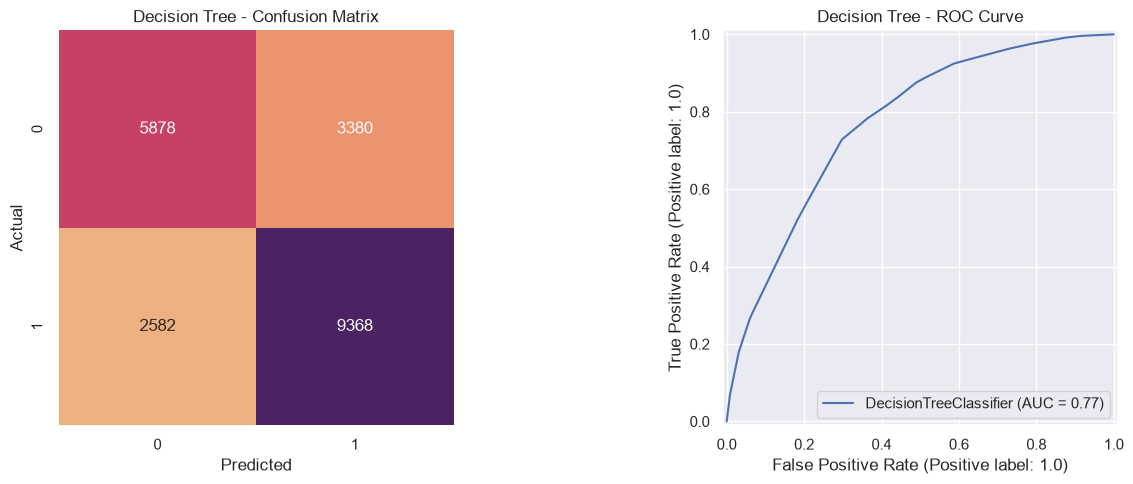

In [ ]:
best_decision_tree = decision_tree_search.best_estimator_

model_train_test(
    disease="Hypertension",
    model_name="Decision Tree",
    model=best_decision_tree
)

### Model Evaluation

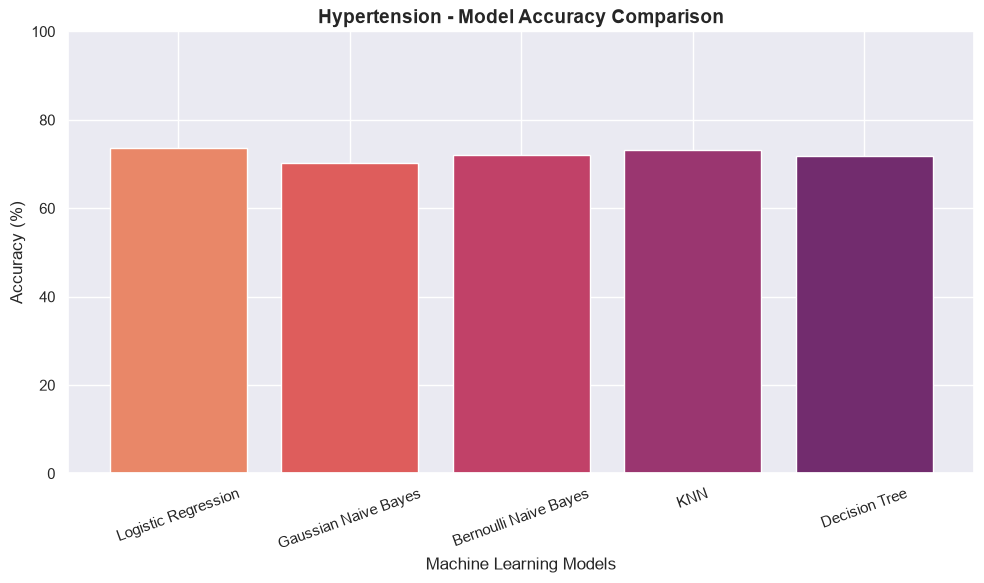

In [ ]:
plot_bar('Hypertension')

## 4.3 Diabetes Prediction


### Data Preparation

In [ ]:
# Split Features (X) and Target Variable (y)

X = df.drop("Diabetes", axis=1)
y = df["Diabetes"]



# Split the Dataset into Training and Testing Sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)



# Display the Dimensions of the Training and Testing Sets

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)



# Feature Scaling

scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

Training Features : (49484, 17)
Testing Features  : (21208, 17)
Training Labels   : (49484,)
Testing Labels    : (21208,)


### Model Training

**LOGISTIC REGRESSION**

c:\Users\USER\.pyenv\pyenv-win\versions\3.12.10\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\USER\.pyenv\pyenv-win\versions\3.12.10\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Accuracy: 74.74%

              precision    recall  f1-score   support

         0.0       0.76      0.72      0.74     10604
         1.0       0.74      0.77      0.75     10604

    accuracy                           0.75     21208
   macro avg       0.75      0.75      0.75     21208
weighted avg       0.75      0.75      0.75     21208



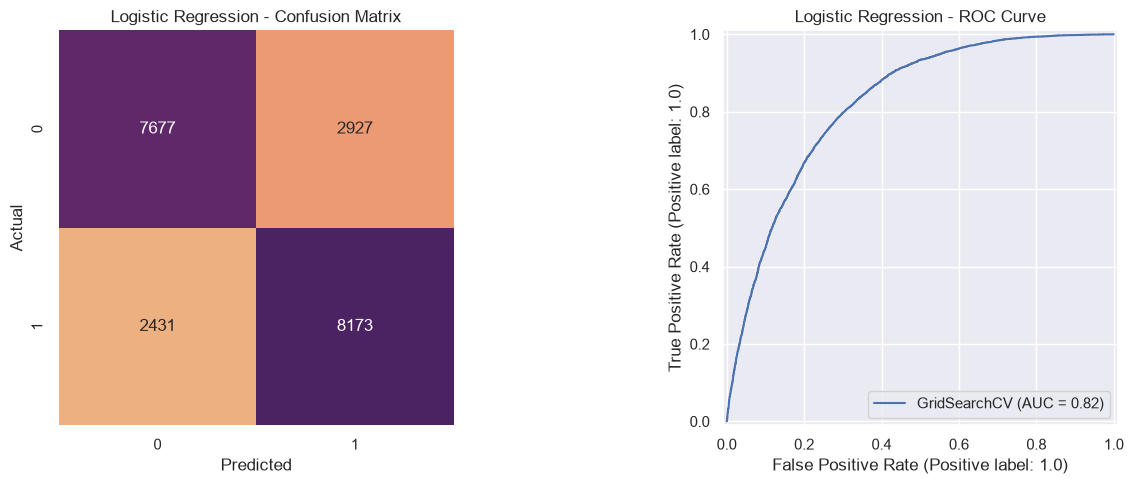

In [ ]:
# Logistic Regression with Hyperparameter Tuning

param_grid = {
    "C": np.logspace(-3, 3, 7),
    "penalty": ["l1", "l2"]
}

logistic_model = GridSearchCV(
    estimator=LogisticRegression(
        class_weight="balanced",
        solver="liblinear",
        random_state=42
    ),
    param_grid=param_grid,
    cv=10,
    scoring="accuracy",
    n_jobs=-1
)

model_train_test(
    disease="Diabetes",
    model_name="Logistic Regression",
    model=logistic_model
)

**GAUSSIAN NAIVE BAYES**

Accuracy: 72.29%

              precision    recall  f1-score   support

         0.0       0.72      0.73      0.72     10604
         1.0       0.73      0.72      0.72     10604

    accuracy                           0.72     21208
   macro avg       0.72      0.72      0.72     21208
weighted avg       0.72      0.72      0.72     21208



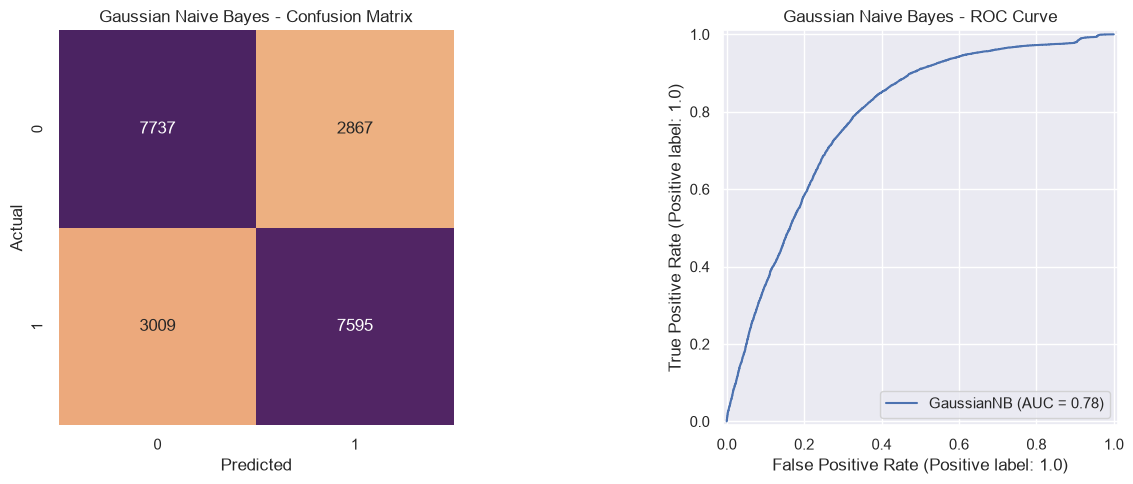

In [ ]:
# Gaussian Naive Bayes

gaussian_nb = GaussianNB()

model_train_test(
    disease="Diabetes",
    model_name="Gaussian Naive Bayes",
    model=gaussian_nb
)

**BERNOULLI NAIVE BAYES**

Accuracy: 73.11%

              precision    recall  f1-score   support

         0.0       0.73      0.73      0.73     10604
         1.0       0.73      0.74      0.73     10604

    accuracy                           0.73     21208
   macro avg       0.73      0.73      0.73     21208
weighted avg       0.73      0.73      0.73     21208



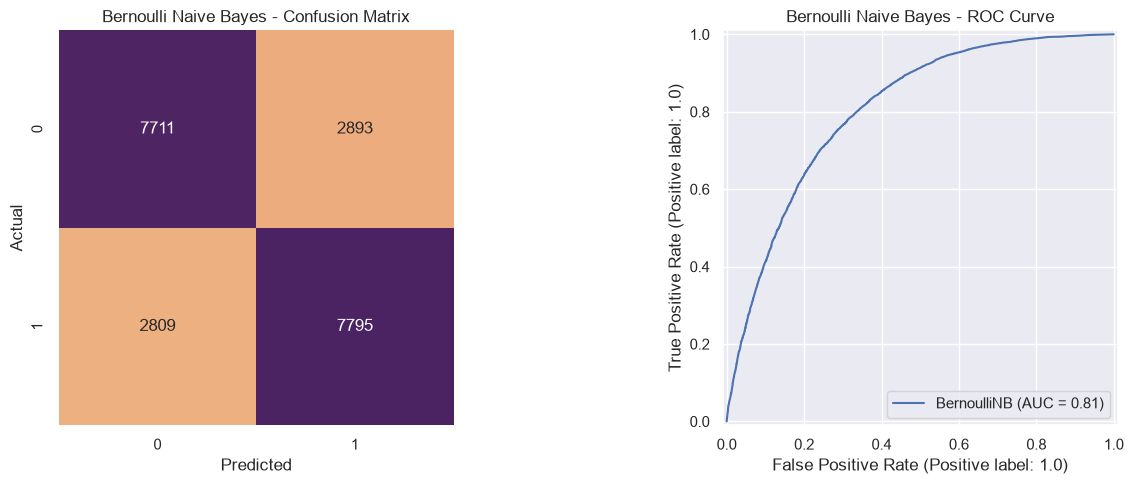

In [ ]:
# Bernoulli Naive Bayes

bernoulli_nb = BernoulliNB()

model_train_test(
    disease="Diabetes",
    model_name="Bernoulli Naive Bayes",
    model=bernoulli_nb
)

**K-NEAREST NEIGHBOURS**

In [ ]:
# K-Nearest Neighbors with Hyperparameter Tuning

param_grid = {
    "n_neighbors": range(1, 20)
}

knn_search = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=10,
    scoring="accuracy",
    n_jobs=-1
)

knn_search.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': range(1, 20)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with hig

In [ ]:
# Best Hyperparameter

print("Best Parameters:", knn_search.best_params_)

best_cv_accuracy = knn_search.best_score_ * 100

print(f"Best Cross-Validation Accuracy: {best_cv_accuracy:.2f}%")

Best Parameters: {'n_neighbors': 19}
Best Cross-Validation Accuracy: 73.59%


Accuracy: 73.58%

              precision    recall  f1-score   support

         0.0       0.76      0.68      0.72     10604
         1.0       0.71      0.79      0.75     10604

    accuracy                           0.74     21208
   macro avg       0.74      0.74      0.74     21208
weighted avg       0.74      0.74      0.74     21208



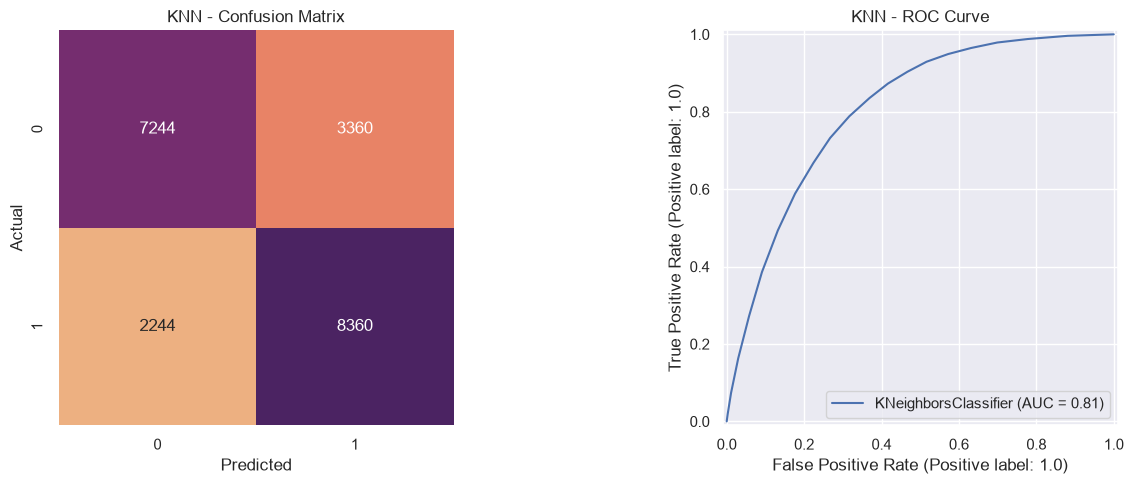

In [ ]:
# K-Nearest Neighbors

best_knn = knn_search.best_estimator_

model_train_test(
    disease="Diabetes",
    model_name="KNN",
    model=best_knn
)

**DECISION TREE**

In [ ]:
# Decision Tree with Hyperparameter Tuning

param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [5, 6, 7, 8, 9],
    "max_features": ["sqrt", "log2"],
    "ccp_alpha": [0.1, 0.01, 0.001]
}

decision_tree_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

decision_tree_search.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'ccp_alpha': [0.1, 0.01, ...], 'criterion': ['gini', 'entropy'], 'max_depth': [5, 6, ...], 'max_features': ['sqrt', 'log2']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True


In [ ]:
# Best Hyperparameters

print("Best Parameters:", decision_tree_search.best_params_)

best_cv_accuracy = decision_tree_search.best_score_ * 100

print(f"Best Cross-Validation Accuracy: {best_cv_accuracy:.2f}%")

Best Parameters: {'ccp_alpha': 0.001, 'criterion': 'gini', 'max_depth': 5, 'max_features': 'sqrt'}
Best Cross-Validation Accuracy: 72.80%


Accuracy: 72.40%

              precision    recall  f1-score   support

         0.0       0.75      0.67      0.71     10604
         1.0       0.70      0.78      0.74     10604

    accuracy                           0.72     21208
   macro avg       0.73      0.72      0.72     21208
weighted avg       0.73      0.72      0.72     21208



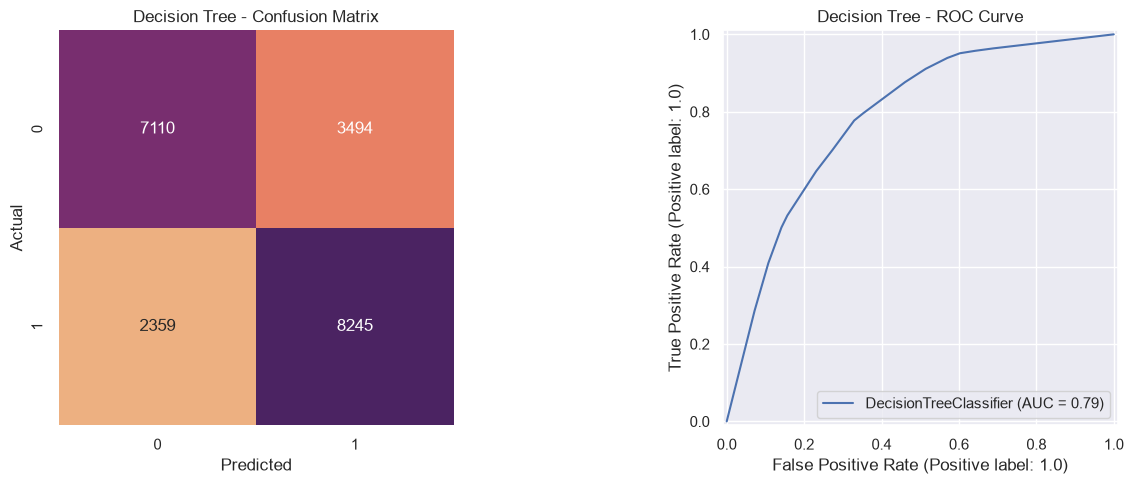

In [ ]:
# Decision Tree

best_decision_tree = decision_tree_search.best_estimator_

model_train_test(
    disease="Diabetes",
    model_name="Decision Tree",
    model=best_decision_tree
)

### Model Evaluation

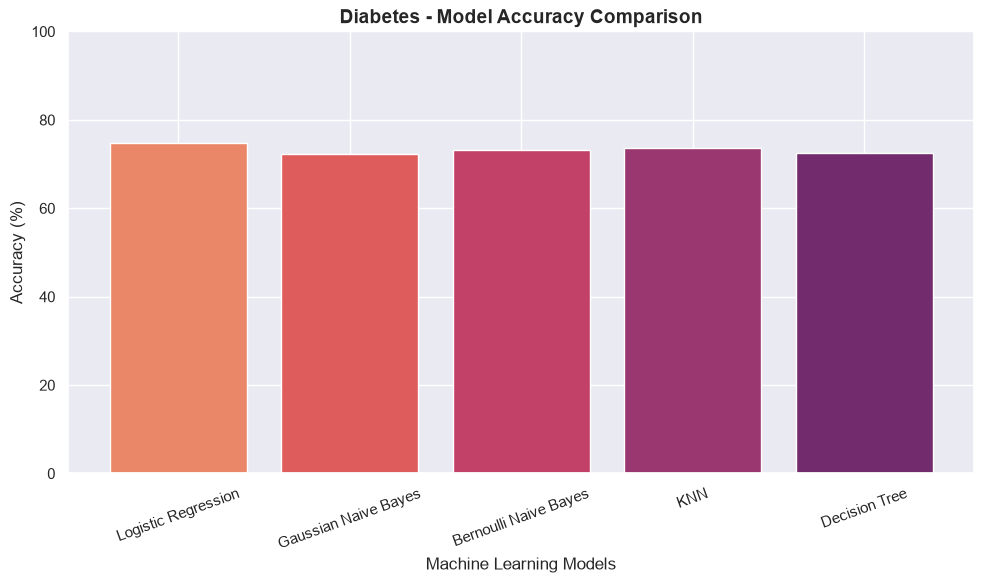

In [ ]:
plot_bar('Diabetes')